In [148]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import scipy
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
import lmfit
import ray
import os
import timeit
from spectral import BandResampler

from bio_optics.water import absorption, attenuation, backscattering, scattering, lee
from bio_optics.atmosphere import downwelling_irradiance
from bio_optics.models import hereon, model
from bio_optics.helper import resampling, utils, owt, indices, plotting
from bio_optics.water import fluorescence

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
%reload_ext autoreload

In [5]:
## check, that the correct version is loaded:
import bio_optics
bio_optics.water.__file__

'c:\\users\\dagmar\\pycharmprojects\\bio_optics\\bio_optics\\water\\__init__.py'

# MOMO reflectances  
With and without glint.

In [8]:
locName = 'mueggelsee' #'silja-helsinki' # finnmaid-helsinki, mueggelsee-berlin

partFname = "HEATWISE_D2.1.0_RD-" + locName
versionNumber = 'v2.0' # helsinki: v1.0, mueggelsee-berlin: default: v0.2 - updated MOMO model

## Select Type:
# 'Rrs': from above water radiation measures with glint
# 'RrsNoGlint': from below water surface, with Lee et al 2011 conversion to above surface Rrs
RrsType = 'RrsNoGlint' 

if locName == "silja-helsinki":
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\"
if locName == 'finnmaid-helsinki':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\"
if locName == 'mueggelsee':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\"


In [9]:
## Simulated spectra MOMO Rrs

def read_spectra(path, fname):
    Rrs = pd.read_csv(path + fname, header=0)
    Rrs['date'] = pd.to_datetime(Rrs['date'])
    Rrs = Rrs.set_index('date')
    # wl = np.arange(400, 1000, 5)
    # wlStr = [str(a) for a in wl]
    # wl = np.asarray([float(a) for a in Rrs.columns.values])

    # varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum']
    varList = ['QWIP']
    owtDF = Rrs[varList].copy()
    Rrs = Rrs.drop(columns=varList)
    wl = np.asarray([float(a) for a in Rrs.columns.values])
    wlstr = [str(a) for a in wl]
    return Rrs, wl, wlstr, owtDF


fname = os.listdir(path)
fname = [fn for fn in fname if 'Rrs_' + versionNumber in fn]
Rrs_glint, wl, wlstr, owtDF_glint = read_spectra(path, fname[0])

fname = os.listdir(path)
fname = [fn for fn in fname if 'RrsNoGlint_'+ versionNumber in fn]
Rrs_noglint, wl, wlstr, owtDF_noglint = read_spectra(path, fname[0])


['2016-03-29T00:00:00.000000000' '2016-11-21T00:00:00.000000000'
 '2017-09-04T00:00:00.000000000' '2017-10-16T00:00:00.000000000'
 '2017-11-13T00:00:00.000000000' '2018-01-02T00:00:00.000000000'
 '2019-05-20T00:00:00.000000000' '2019-07-22T00:00:00.000000000']


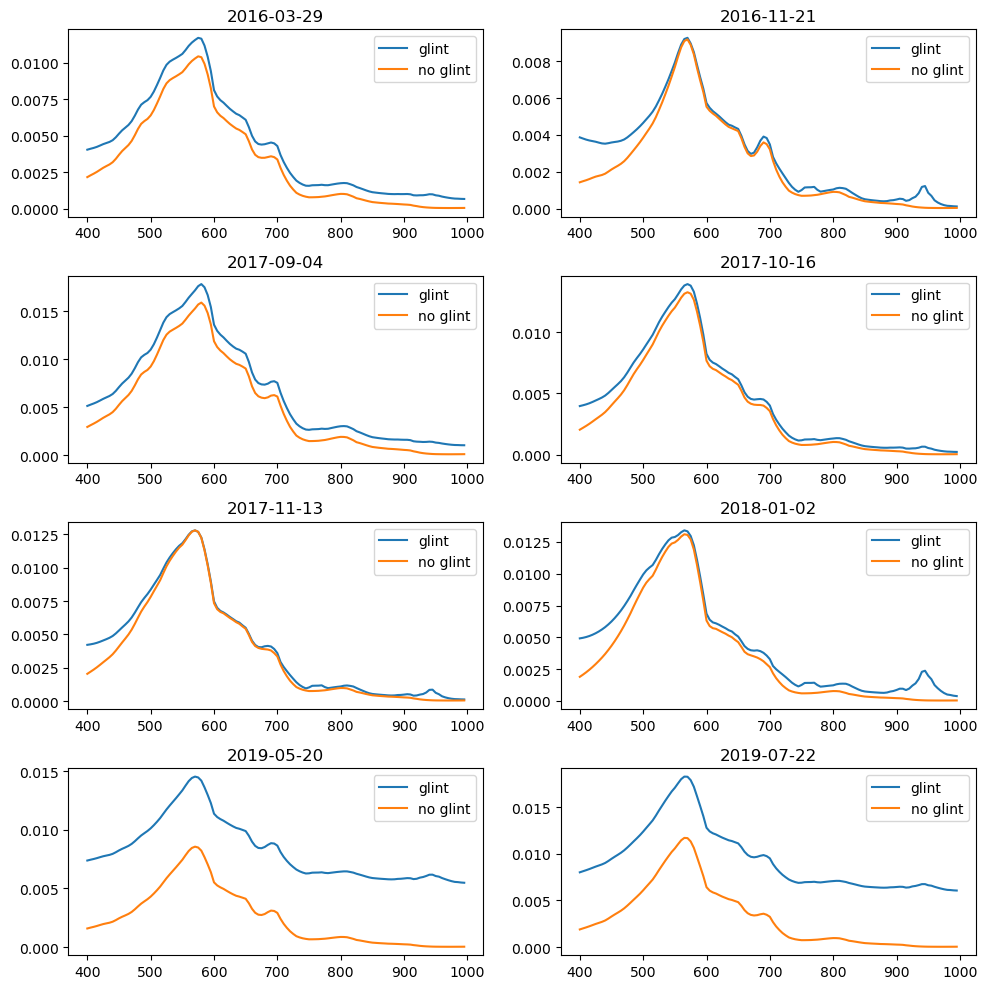

In [11]:
Nx, Ny = (2, 4)
ind = np.sort(np.random.choice(Rrs_glint.index, Nx*Ny, replace=False))
print(ind)
fig, ax = plt.subplots(nrows=Ny, ncols=Nx, figsize=(10,10))
for ix in range(Nx):
    for iy in range(Ny):
        ax[iy, ix].plot(wl, Rrs_glint.loc[ind[iy*Nx + ix]].values, '-', label='glint')
        ax[iy, ix].plot(wl, Rrs_noglint.loc[ind[iy*Nx + ix]].values, '-', label='no glint')
        ax[iy, ix].legend()
        ax[iy, ix].set_title(str(ind[iy*Nx + ix]).split('T')[0])

fig.tight_layout()
plt.show()

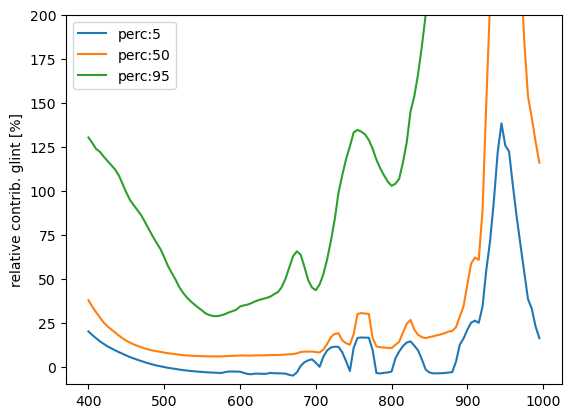

In [82]:
glintTest = (Rrs_glint - Rrs_noglint)/Rrs_noglint
perc = [5, 50, 95]
glintPerc = np.percentile(glintTest, perc, axis=0)
for i, x in enumerate(glintPerc):
    plt.plot(wl, x*100, '-', label='perc:'+str(perc[i]))
plt.legend()
plt.ylim((-10, 200))
plt.ylabel('relative contrib. glint [%]')
plt.show()

# Forward Bi-Model  
- Use insitu data and replace values from inversion (the results ...allOWTS... are organised in the original order)
- model Spectra with Bi bio-optical model

**CAUTION:** For these experiments use the python code in *bio_optics/processors/process_Hyperspectral_multipleOWT_smallFile_20251211.py* 

In [2]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.0058, vary=False)  # Diatoms
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green
    params.add('b_ratio_C_2', value=0.0042, vary=False)  # cryptophyte
    params.add('b_ratio_C_3', value=0.0082, vary=False)  # cyano blue
    params.add('b_ratio_C_4', value=0.001, vary=False)  # cyano red
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    else:
        params.add('b_ratio_C_5', value=0.0129, vary=False)  # coccolithophores , Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.0109, vary=False)  # case-1 , Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=True)  # max=0.0756
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=True)  # max=0.0756
    # params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=True)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.0185, min=0.005, max=0.032, vary=True) # test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=True, vary=False)
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params

In [3]:
# Define wavelength range and sampling rate
wavelengths=np.arange(400,900, 5)

# Select iop-model setup!
AlgaeGroupType = 'HEREON' #'Standard' # 'Standardv2': HEREON, 'Standardv3': 'Standard', NSSummerBloomsv3': 'Summer'


# global inputs that don't change with fit params
a_md_spec_res = absorption.a_md_spec(wavelengths=wavelengths)
a_bd_spec_res = absorption.a_bd_spec(wavelengths=wavelengths)
a_w_res = resampling.resample_a_w(wavelengths=wavelengths)
if AlgaeGroupType == 'HEREON':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
if AlgaeGroupType == 'Standard':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
if AlgaeGroupType == 'Summer':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
b_bw_res = backscattering.b_bw(wavelengths=wavelengths, fresh=False)

da_W_div_dT_res = resampling.resample_da_W_div_dT(wavelengths=wavelengths)
h_C_res = fluorescence.h_C_double(wavelengths=wavelengths, W=0.75)
h_C_phycocyanin_res = fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=644)
h_C_phycoerythrin_res =fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=573)
omega_d_lambda_0_res = attenuation.omega_d_lambda_0()

E_0_res = resampling.resample_E_0(wavelengths=wavelengths)
a_oz_res = resampling.resample_a_oz(wavelengths=wavelengths)
a_ox_res = resampling.resample_a_ox(wavelengths=wavelengths)
a_wv_res = resampling.resample_a_wv(wavelengths=wavelengths)
n2_res = resampling.resample_n(wavelengths=wavelengths)

E_dd_res = downwelling_irradiance.E_dd(wavelengths=wavelengths)
E_dsa_res = downwelling_irradiance.E_dsa(wavelengths=wavelengths)
E_dsr_res = downwelling_irradiance.E_dsr(wavelengths=wavelengths)
E_d_res = E_dd_res + E_dsa_res + E_dsr_res

# Consistency check implementations  
Reference is the web-based HEREON model implementation.  
Test systematically, that our IOPs are correctly implemented.  

## Read all data

In [137]:
# general list of inversion versions available
# Determines: inversion dict and forward dict 
versionInvList = ['Inv0.4b']  # Mueggelsee: Inv0.4, Inv0.4b: includes offset in ad_spec!
colorList = ['aqua', 'lightblue', 'grey']

### Read MOMO data

In [12]:
## Simulated spectra MOMO Rrs
locName = 'mueggelsee' #'silja-helsinki' # finnmaid-helsinki, mueggelsee-berlin

partFname = "HEATWISE_D2.1.0_RD-" + locName
versionNumber = 'v2.0' # helsinki: v1.0, mueggelsee-berlin: default: v0.2 - updated MOMO model

## Select Type:
# 'Rrs': from above water radiation measures with glint
# 'RrsNoGlint': from below water surface, with Lee et al 2011 conversion to above surface Rrs
RrsType = 'RrsNoGlint' 

if locName == "silja-helsinki":
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\"
if locName == 'finnmaid-helsinki':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\"
if locName == 'mueggelsee':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\"

## Simulated spectra MOMO Rrs
def read_spectra(path, fname):
    Rrs = pd.read_csv(path + fname, header=0)
    Rrs['date'] = pd.to_datetime(Rrs['date'])
    Rrs = Rrs.set_index('date')
    # wl = np.arange(400, 1000, 5)
    # wlStr = [str(a) for a in wl]
    # wl = np.asarray([float(a) for a in Rrs.columns.values])

    # varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum']
    varList = ['QWIP']
    owtDF = Rrs[varList].copy()
    Rrs = Rrs.drop(columns=varList)
    wl = np.asarray([float(a) for a in Rrs.columns.values])
    wlstr = [str(a) for a in wl]
    return Rrs, wl, wlstr, owtDF


fname = os.listdir(path)
fname = [fn for fn in fname if RrsType +'_' + versionNumber in fn]
print(fname)
Rrs_momo, wl_momo, wlstr_momo, owtDF_momo = read_spectra(path, fname[0])

['HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-RrsNoGlint_v2.0.csv']


### Read Inversion data (all versions)  

In [15]:
## Inversion data (IOPs and Simulations)
path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\FullInversion\\"

positionList = ['helsinki_ss', 'helsinki_fm', 'berlin_muggelsee']
timezoneList = ['Etc/GMT', 'Etc/GMT', 'Etc/GMT']

position = positionList[2]
timezone = 'Etc/GMT'

simDict = {}
invDict = {}
wlinvDict = {}

invFname = os.listdir(path)
invFname = [fn for fn in invFname if position in fn ]  #and 'allOWTs_'+versionInv+'.txt' in fn
invFname
# for versionInv in versionInvList:
#     invFname = os.listdir(path)
#     invFname = [fn for fn in invFname if position in fn and 'allOWTs_'+versionInv+'.txt' in fn]  
#     print(invFname)
    
#     inv = pd.read_csv(path + invFname[0])
#     inv['date'] = pd.to_datetime(inv['date']) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
#     inv = inv.set_index('date')
#     invDict[versionInv] = inv
    
#     sim = pd.read_csv(path + invFname[1])
#     sim['date'] = pd.to_datetime(sim['date']) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
#     sim = sim.set_index('date')
#     simDict[versionInv] = sim

#     wlinv = np.asarray([float(a) for a in sim.columns.values[1:]])
#     wlinvDict[versionInv] = wlinv

[]

### Read insitu IOP data  

In [265]:
## IOP Input to simulations
inputPath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\"
metaDict = {'helsinki_ss': {'folder': 'Helsinki\\input_simulations' , 'fileName':  'helsinki_silja_serenade_IOP_v0.1b.csv'}, # helsinki_silja_serenade_daily_v0.3.cvs
         'helsinki_fm': {'folder': 'Helsinki\\input_simulations', 'fileName': 'helsinki_finnmaid_daily_v0.3.csv'}, 
        'berlin_muggelsee': {'folder': 'Muggelsee - Berlin\\input_simulations' ,  'fileName': 'berlin_muggelsee_IOP_daily_v0.3.csv'}, # 'fileName': 'berlin_muggelsee_IOP_daily_v0.3_SZA_Gx.csv'
       }


folder = metaDict[position]['folder']
fname = metaDict[position]['fileName']

insitu = pd.read_csv(inputPath + folder + '\\'+ fname)
timeList = ['date', 'datetime', 'valid_time', 'DATE']
timeVarname = [a for a in timeList if a in insitu.columns.values]
print(timeVarname)
timeTest = np.asarray([str(t).split(' ')[0] for t in insitu[timeVarname[0]].values])
insitu['date'] = pd.to_datetime(timeTest) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
insitu = insitu.set_index('date')
insitu.columns.values

['datetime']


array(['datetime', 'Temp °C', 'Salinity [PSU]', 'Chlg [µg/l]',
       'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]',
       'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]', 'ag(440) [1/m]',
       'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]',
       'anap_spec(440) [m2 g-1]', 'Snap [1/nm]', 'latitude_station',
       'longitude_station', 'latitude_cams', 'longitude_cams', 'u10',
       'v10', 'bcaod550', 'duaod550', 'omaod550', 'ssaod550', 'aod469',
       'aod550', 'aod670', 'aod865', 'aod1240', 'tc_ch4', 'gtco3', 'tcwv',
       'G0w', 'G1w', 'G0p', 'G1p', 'SZA'], dtype=object)

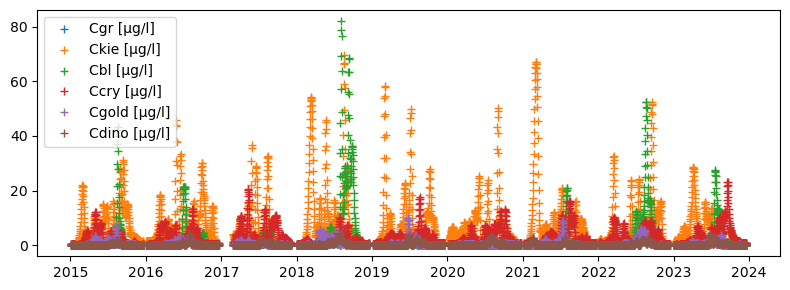

In [22]:
varList = ['Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]', 'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]']
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,3))
for v in varList:
    ID = np.array(insitu[v].values > 0)
    if np.sum(ID)>0:
        ax.plot(insitu[v].loc[ID], '+', label=v)
ax.legend()
fig.tight_layout()
plt.show()

In [43]:
# select data
ID = insitu['NAP [mg/l]'].values == np.nanmin(insitu['NAP [mg/l]'].values)

outVarList = ['Chlg [µg/l]', 'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]', 'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]',
       'ag(440) [1/m]', 'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]']

# print(insitu[outVarList].loc[ID,:])
# np.arange(0, len(ID),1)[ID]

# print(insitu[outVarList].iloc[0,:])
# varList2 = ['Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]',  'Ccry [µg/l]']
# print(insitu[varList2].iloc[0,:].values/insitu['Chlg [µg/l]'].iloc[0])

### Read forward model insitu in phytomix implementation (all versions)
versions are based on Inversion data version.  
**There should be a second version with regard to the changes in forward modelling!**


In [138]:
fwpath = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
# fname = "SimRrs_InsituForward_HEREONorig_Standardinverted_IOP_bio_optics_HEREONfull_CHIME_sim_HEATWISE_Helsinki_SiljaSerenade_allOWTs_v0.1.txt"
# fw = pd.read_csv(fwpath + fname, header=0, sep='\t')
# fw_wl = np.asarray([float(a) for a in fw.columns.values])

fwDict = {}

for versionInv in versionInvList:
    fwFname = os.listdir(fwpath)
    fwFname = [fn for fn in fwFname if position in fn and versionInv in fn] 
    print(fwFname)

    fw = pd.read_csv(fwpath + fwFname[0], sep='\t')
    # fw['date'] = pd.to_datetime(fw['date']) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
    # fw = fw.set_index('date')

    fwDict[versionInv] = fw
    fw_wl = np.asarray([float(a) for a in fw.columns.values])

['SimRrs_InsituForward_HEREONorig_HEREONgold_berlin_muggelsee_IOP_daily_v0_Inv0.4b.txt']


### Read spectral IOPs from Bi,Shun web-implement

In [12]:
# fpath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\IOP_spectra_outputs_webHEREON_HelsinkiSS_spectrum0.csv"
# fpath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\IOP_spectra_outputs_webHEREON_HelsinkiSS_spectrum234.csv"
fpath = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\concistency\IOP_spectra_outputs_webHEREON_oder_frankfurt_spectrum90.csv" #0, 90
bi = pd.read_csv(fpath, header=0)
bi

,wavelen,aph,ad,acdom,bph,bd,aw,bw,ap,agp,bp,at,bt,bbph,bbd,bbp,bbw,bbt,Rrs_L11,Rrs_AM03
0,350,0.644607,3.214096,3.196778,5.648302,13.905031,0.000879,0.009947,3.858704,7.055482,19.553333,7.056361,19.563281,0.018357,0.300349,0.318706,0.004974,0.323679,0.002027,0.002172
1,352,0.644608,3.151110,3.068023,5.644803,13.930650,0.000910,0.009701,3.795718,6.863741,19.575452,6.864651,19.585153,0.018346,0.300902,0.319248,0.004850,0.324098,0.002091,0.002242
2,354,0.644609,3.089531,2.945174,5.641325,13.955154,0.000950,0.009461,3.734139,6.679314,19.596479,6.680264,19.605941,0.018334,0.301431,0.319766,0.004731,0.324496,0.002156,0.002314
3,356,0.644611,3.029326,2.828378,5.637869,13.978572,0.000991,0.009230,3.673936,6.502314,19.616441,6.503305,19.625671,0.018323,0.301937,0.320260,0.004615,0.324875,0.002222,0.002387
4,358,0.644614,2.970464,2.717424,5.634432,14.000933,0.001035,0.009005,3.615078,6.332501,19.635365,6.333537,19.644370,0.018312,0.302420,0.320732,0.004503,0.325235,0.002290,0.002461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,892,0.000006,0.335055,0.000122,5.751148,11.623172,6.302232,0.000197,0.335062,0.335184,17.374320,6.637416,17.374517,0.018691,0.251061,0.269752,0.000098,0.269850,0.001775,0.001901
272,894,0.000006,0.334865,0.000118,5.749928,11.613095,6.407523,0.000195,0.334871,0.334989,17.363023,6.742512,17.363218,0.018687,0.250843,0.269530,0.000097,0.269628,0.001744,0.001866
273,896,0.000005,0.334679,0.000113,5.748710,11.603046,6.502164,0.000193,0.334685,0.334798,17.351757,6.836962,17.351950,0.018683,0.250626,0.269309,0.000097,0.269406,0.001716,0.001836
274,898,0.000005,0.334497,0.000109,5.747496,11.593025,6.608917,0.000191,0.334502,0.334611,17.340521,6.943528,17.340712,0.018679,0.250409,0.269089,0.000096,0.269184,0.001687,0.001804


### WASI 6 test

In [29]:
# fpath = "C:\WASI6\DATA\\user\\1b.FWD" NAP as C_X, default parameters
# fpath = "C:\WASI6\DATA\\user\\1c.FWD" # NAP as Mie
fpath = "C:\WASI6\DATA\\user\\1d_Cx.FWD" # NAP as C_X, changed anap_spec, Snap, Sg
gg = pd.read_csv(fpath, sep='\t', skiprows=11, names=['wavelen', 'Rrs', ''], index_col=False)
#gg.columns.values = ['wavelen', 'Rrs']
gg

,wavelen,Rrs,
0,380.0,0.000993,NaN
1,381.0,0.001007,NaN
2,382.0,0.001022,NaN
3,383.0,0.001036,NaN
4,384.0,0.001050,NaN
...,...,...,...
616,996.0,0.000017,NaN
617,997.0,0.000017,NaN
618,998.0,0.000017,NaN
619,999.0,0.000017,NaN


# Analyse Muggelsee  
compare:
- MOMO spectra
- forward Bi&Hieronymi spectra (including Goldalgae instead of coccolithophores)
- (inversion results)
- web Version Bi&Hieronymi

In [47]:
ind

array(['2015-10-26T00:00:00.000000000', '2016-05-23T00:00:00.000000000',
       '2017-09-04T00:00:00.000000000', '2018-02-05T00:00:00.000000000',
       '2018-07-16T00:00:00.000000000', '2020-02-10T00:00:00.000000000',
       '2020-04-14T00:00:00.000000000', '2020-07-27T00:00:00.000000000',
       '2020-09-28T00:00:00.000000000', '2020-11-09T00:00:00.000000000',
       '2023-11-06T00:00:00.000000000', '2023-12-18T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [48]:
fpath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\webHEREON\\" 
fnamesList = os.listdir(fpath)
fnamesList = [fn for fn in fnamesList if 'Mueggelsee' in fn]

biDict = {}
for id_ in ind:
    key = str(id_).split('T')[0]
    fname = [fn for fn in fnamesList if key.replace('-', '') in fn]
    bi = pd.read_csv(fpath+fname[0], header=0)
    biDict[key] = bi


In [259]:
## read BC forward bi&Hi with SZA angle dependency, OZA=0°
spath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
fname2 = "SimRrs_InsituForward_HEREONgold_berlin_muggelsee_IOP_daily_v0_Inv0.4_AngleDepSZA.txt"
fw_sza = pd.read_csv(spath + fname2, header=0, sep='\t')
fw_sza = fw_sza.set_index(insitu.index)
fw_sza

,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,890.0,891.0,892.0,893.0,894.0,895.0,896.0,897.0,898.0,899.0
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,0.001425,0.001446,0.001468,0.001490,0.001513,0.001536,0.001558,0.001582,0.001605,0.001629,...,0.000149,0.000148,0.000146,0.000145,0.000143,0.000142,0.000141,0.000139,0.000138,0.000137
2015-01-06,0.001405,0.001427,0.001448,0.001470,0.001492,0.001515,0.001537,0.001560,0.001583,0.001607,...,0.000145,0.000144,0.000142,0.000141,0.000139,0.000138,0.000137,0.000136,0.000134,0.000133
2015-01-07,0.001386,0.001407,0.001429,0.001450,0.001472,0.001494,0.001516,0.001539,0.001562,0.001585,...,0.000141,0.000140,0.000139,0.000137,0.000136,0.000135,0.000133,0.000132,0.000131,0.000130
2015-01-08,0.001367,0.001388,0.001409,0.001431,0.001452,0.001474,0.001496,0.001518,0.001541,0.001564,...,0.000138,0.000136,0.000135,0.000134,0.000132,0.000131,0.000130,0.000129,0.000127,0.000126
2015-01-09,0.001349,0.001370,0.001390,0.001411,0.001433,0.001454,0.001476,0.001498,0.001520,0.001543,...,0.000134,0.000133,0.000132,0.000130,0.000129,0.000128,0.000127,0.000125,0.000124,0.000123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-14,0.001157,0.001175,0.001193,0.001210,0.001229,0.001247,0.001265,0.001284,0.001303,0.001322,...,0.000138,0.000136,0.000135,0.000134,0.000132,0.000131,0.000130,0.000129,0.000127,0.000126
2023-12-15,0.001176,0.001194,0.001212,0.001230,0.001249,0.001267,0.001286,0.001305,0.001324,0.001344,...,0.000141,0.000140,0.000138,0.000137,0.000136,0.000134,0.000133,0.000132,0.000131,0.000129
2023-12-16,0.001193,0.001211,0.001229,0.001248,0.001266,0.001285,0.001304,0.001323,0.001343,0.001363,...,0.000144,0.000143,0.000141,0.000140,0.000139,0.000137,0.000136,0.000135,0.000133,0.000132


In [271]:
## read BC forward bi&Hi with SZA angle dependency, OZA=30°
spath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
fname3 = "SimRrs_InsituForward_HEREONgold_berlin_muggelsee_IOP_daily_v0_Inv0.4_AngleDepSZA_OZA.txt"
fw_sza2 = pd.read_csv(spath + fname3, header=0, sep='\t')
fw_sza2 = fw_sza2.set_index(insitu.index)
fw_sza2

,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,890.0,891.0,892.0,893.0,894.0,895.0,896.0,897.0,898.0,899.0
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,0.001673,0.001699,0.001725,0.001752,0.001779,0.001806,0.001833,0.001861,0.001889,0.001918,...,0.000184,0.000182,0.000181,0.000179,0.000177,0.000175,0.000174,0.000172,0.000170,0.000169
2015-01-06,0.001649,0.001675,0.001701,0.001727,0.001753,0.001780,0.001807,0.001835,0.001862,0.001890,...,0.000179,0.000178,0.000176,0.000174,0.000172,0.000171,0.000169,0.000168,0.000166,0.000164
2015-01-07,0.001625,0.001650,0.001676,0.001702,0.001728,0.001754,0.001781,0.001808,0.001836,0.001863,...,0.000175,0.000173,0.000171,0.000170,0.000168,0.000166,0.000165,0.000163,0.000162,0.000160
2015-01-08,0.001602,0.001627,0.001652,0.001678,0.001703,0.001729,0.001756,0.001782,0.001809,0.001837,...,0.000170,0.000169,0.000167,0.000165,0.000164,0.000162,0.000161,0.000159,0.000158,0.000156
2015-01-09,0.001579,0.001604,0.001629,0.001654,0.001679,0.001705,0.001731,0.001757,0.001784,0.001811,...,0.000166,0.000164,0.000163,0.000161,0.000160,0.000158,0.000157,0.000155,0.000154,0.000152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-14,0.001356,0.001377,0.001399,0.001420,0.001442,0.001464,0.001486,0.001508,0.001531,0.001554,...,0.000170,0.000168,0.000167,0.000165,0.000163,0.000162,0.000160,0.000159,0.000157,0.000156
2023-12-15,0.001380,0.001401,0.001423,0.001445,0.001467,0.001489,0.001511,0.001534,0.001557,0.001580,...,0.000174,0.000172,0.000171,0.000169,0.000168,0.000166,0.000164,0.000163,0.000161,0.000160
2023-12-16,0.001400,0.001422,0.001444,0.001466,0.001488,0.001511,0.001534,0.001557,0.001580,0.001604,...,0.000178,0.000176,0.000175,0.000173,0.000171,0.000170,0.000168,0.000166,0.000165,0.000163


In [276]:
## read BC forward bi&Hi with SZA angle dependency, OZA=30°
spath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
fname3_ = "SimRrs_InsituForward_HEREONgold_berlin_muggelsee_IOP_daily_v0_Inv0.4_AngleDepSZA_OZA2.txt"
fw_sza3 = pd.read_csv(spath + fname3_, header=0, sep='\t')
fw_sza3 = fw_sza3.set_index(insitu.index)
fw_sza3

,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,890.0,891.0,892.0,893.0,894.0,895.0,896.0,897.0,898.0,899.0
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,0.001993,0.002024,0.002056,0.002088,0.002120,0.002153,0.002186,0.002219,0.002253,0.002287,...,0.000228,0.000226,0.000224,0.000222,0.000219,0.000217,0.000215,0.000213,0.000211,0.000209
2015-01-06,0.001962,0.001993,0.002025,0.002056,0.002088,0.002120,0.002153,0.002186,0.002219,0.002253,...,0.000222,0.000220,0.000218,0.000216,0.000214,0.000212,0.000210,0.000208,0.000206,0.000204
2015-01-07,0.001933,0.001963,0.001994,0.002025,0.002057,0.002089,0.002121,0.002153,0.002186,0.002220,...,0.000216,0.000214,0.000212,0.000210,0.000208,0.000206,0.000204,0.000202,0.000200,0.000199
2015-01-08,0.001904,0.001934,0.001964,0.001995,0.002026,0.002057,0.002089,0.002121,0.002154,0.002187,...,0.000211,0.000209,0.000207,0.000205,0.000203,0.000201,0.000199,0.000197,0.000195,0.000193
2015-01-09,0.001876,0.001905,0.001935,0.001966,0.001996,0.002027,0.002058,0.002090,0.002122,0.002155,...,0.000206,0.000204,0.000202,0.000200,0.000198,0.000196,0.000194,0.000192,0.000190,0.000189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-14,0.001614,0.001639,0.001665,0.001691,0.001717,0.001744,0.001770,0.001798,0.001825,0.001853,...,0.000211,0.000208,0.000206,0.000204,0.000202,0.000201,0.000199,0.000197,0.000195,0.000193
2023-12-15,0.001643,0.001669,0.001695,0.001721,0.001748,0.001775,0.001802,0.001829,0.001857,0.001885,...,0.000216,0.000214,0.000212,0.000210,0.000208,0.000206,0.000204,0.000202,0.000200,0.000198
2023-12-16,0.001668,0.001695,0.001721,0.001748,0.001775,0.001802,0.001829,0.001857,0.001886,0.001914,...,0.000221,0.000218,0.000216,0.000214,0.000212,0.000210,0.000208,0.000206,0.000204,0.000202


In [139]:
fw = fw.set_index(insitu.index)
fw

,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,890.0,891.0,892.0,893.0,894.0,895.0,896.0,897.0,898.0,899.0
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,0.001302,0.001321,0.001341,0.001361,0.001381,0.001401,0.001421,0.001442,0.001463,0.001485,...,0.000124,0.000122,0.000121,0.000120,0.000119,0.000118,0.000117,0.000115,0.000114,0.000113
2015-01-06,0.001285,0.001304,0.001324,0.001343,0.001363,0.001383,0.001403,0.001424,0.001445,0.001466,...,0.000120,0.000119,0.000118,0.000117,0.000116,0.000115,0.000113,0.000112,0.000111,0.000110
2015-01-07,0.001269,0.001288,0.001307,0.001326,0.001346,0.001365,0.001385,0.001406,0.001426,0.001447,...,0.000117,0.000116,0.000115,0.000114,0.000113,0.000111,0.000110,0.000109,0.000108,0.000107
2015-01-08,0.001253,0.001271,0.001290,0.001309,0.001329,0.001348,0.001368,0.001388,0.001408,0.001428,...,0.000114,0.000113,0.000112,0.000111,0.000110,0.000109,0.000108,0.000107,0.000106,0.000105
2015-01-09,0.001237,0.001256,0.001274,0.001293,0.001312,0.001331,0.001350,0.001370,0.001390,0.001410,...,0.000111,0.000110,0.000109,0.000108,0.000107,0.000106,0.000105,0.000104,0.000103,0.000102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-14,0.001061,0.001076,0.001092,0.001108,0.001124,0.001140,0.001157,0.001174,0.001190,0.001208,...,0.000114,0.000113,0.000112,0.000111,0.000110,0.000109,0.000108,0.000107,0.000106,0.000105
2023-12-15,0.001077,0.001093,0.001109,0.001125,0.001141,0.001158,0.001175,0.001192,0.001209,0.001226,...,0.000117,0.000116,0.000115,0.000114,0.000113,0.000112,0.000111,0.000110,0.000109,0.000108
2023-12-16,0.001091,0.001107,0.001123,0.001140,0.001156,0.001173,0.001190,0.001207,0.001225,0.001242,...,0.000120,0.000119,0.000118,0.000116,0.000115,0.000114,0.000113,0.000112,0.000111,0.000110


In [277]:
ID = np.intersect1d(fw.index, Rrs_momo.index)
fw_sel = fw.loc[ID]
iop_insitu_sel = insitu.loc[ID]
fw_sza_sel= fw_sza.loc[ID]
fw_sza2_sel= fw_sza2.loc[ID]
fw_sza3_sel= fw_sza3.loc[ID]

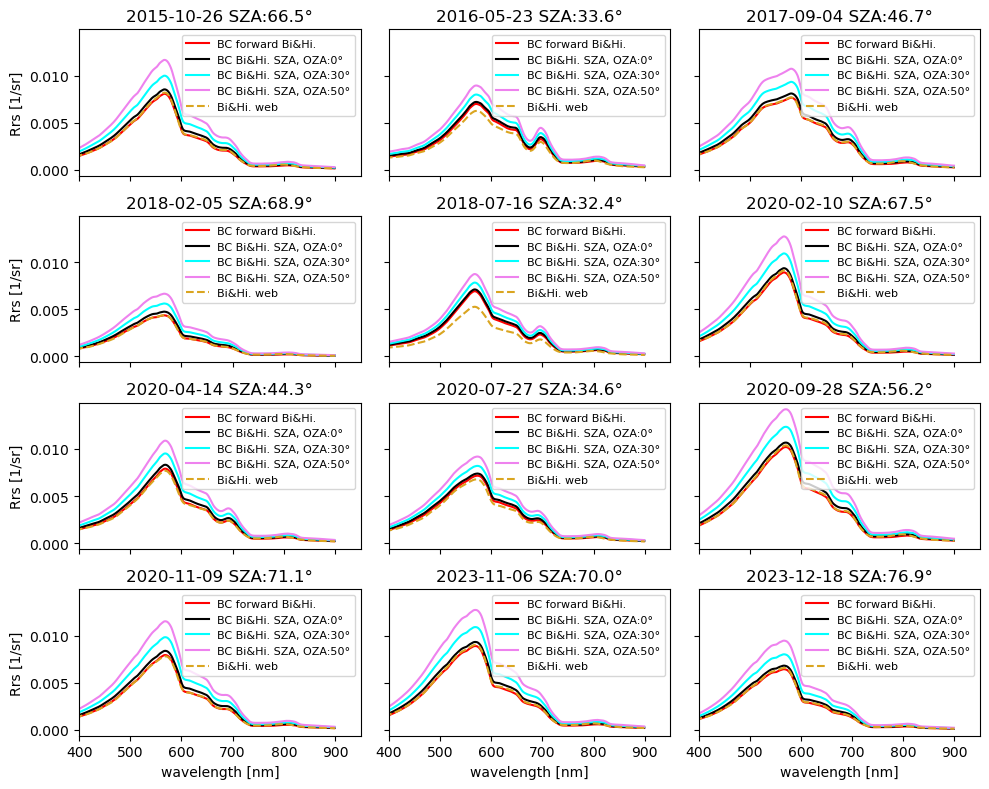

In [281]:
Nx, Ny = (3,4)
# ind = np.sort(np.random.choice(Rrs_momo.index, Nx*Ny, replace=False))
fig, ax=plt.subplots(nrows=Ny, ncols=Nx, figsize=(10,8), sharex=True, sharey=True)

for iy in range(Ny):
    for ix in range(Nx):
        # ax[iy, ix].plot(wl, Rrs_momo.loc[ind[iy*Nx+ix],:].values, 'b-', label='MOMO '+ RrsType)
        # ax[iy, ix].plot(wl, Rrs_noglint_sel.iloc[iy*Nx+ix,:].values, '-', color='lightblue', label='MOMO '+ RrsType)
        
        ax[iy, ix].plot(fw_wl, fw_sel.loc[ind[iy*Nx+ix],:].values, 'r-', label='BC forward Bi&Hi.')
        ax[iy, ix].plot(fw_wl, fw_sza_sel.loc[ind[iy*Nx+ix],:].values, 'k-', label='BC Bi&Hi. SZA, OZA:0°')
        ax[iy, ix].plot(fw_wl, fw_sza2_sel.loc[ind[iy*Nx+ix],:].values, '-', color='aqua', label='BC Bi&Hi. SZA, OZA:30°') #dAA: 135°
        ax[iy, ix].plot(fw_wl, fw_sza3_sel.loc[ind[iy*Nx+ix],:].values, '-', color='violet', label='BC Bi&Hi. SZA, OZA:50°') #dAA: 135°
        
        d = biDict[str(ind[iy*Nx+ix]).split('T')[0]]
        ax[iy, ix].plot(d['wavelen'].values, d['Rrs_L11'].values, '--', color='goldenrod', label='Bi&Hi. web')
        
        # ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0] + ' NAP:' + str(np.round(iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 2)))
        ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0] + ' SZA:' + str(np.round(iop_insitu_sel['SZA'].loc[ind[iy*Nx+ix]], 1))+'°')
        
        ax[iy, ix].legend(fontsize=8)
        ax[iy, ix].set_xlim((400, 950))
        if iy == Ny-1:
            ax[iy, ix].set_xlabel('wavelength [nm]')
        if ix == 0:
            ax[iy, ix].set_ylabel('Rrs [1/sr]')


fig.tight_layout()
plt.show()

In [44]:
outVarList = ['Chlg [µg/l]', 'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]',
       'ag(440) [1/m]', 'Sg [1/nm]', 'TSPM [mg/l]', 'NAP [mg/l]']

iop_insitu_sel[outVarList].loc[ind]

,Chlg [µg/l],Cgr [µg/l],Ckie [µg/l],Cbl [µg/l],Cbl2 [µg/l],Ccry [µg/l],Cgold [µg/l],Cdino [µg/l],ag(440) [1/m],Sg [1/nm],TSPM [mg/l],NAP [mg/l]
date,,,,,,,,,,,,
2015-10-26,3.9,0.036792,3.467689,0.042286,0.0,0.331132,0.064387,0.001378,0.331480,0.018,2.6,2.176000
2016-05-23,32.1,0.191287,23.471412,0.021037,0.0,7.175842,1.220100,0.041359,0.400349,0.018,5.2,1.821845
2017-09-04,9.4,0.034017,0.238118,0.362847,0.0,8.685645,0.079373,0.001399,0.440523,0.018,4.2,3.370000
2018-02-05,2.3,0.170370,0.915741,0.076728,0.0,1.128704,0.085185,0.003914,0.383132,0.018,1.1,0.992000
2018-07-16,20.9,4.645151,10.675585,0.387625,0.0,1.239130,1.931773,2.020736,0.429044,0.018,4.3,0.531000
2020-02-10,2.9,0.090311,2.568858,0.000733,0.0,0.200692,0.040138,0.003070,0.337219,0.018,2.8,2.511000
2020-04-14,10.2,0.137661,8.298972,0.085219,0.0,1.376607,0.301542,0.003070,0.354437,0.018,3.8,2.244000
2020-07-27,8.7,0.079817,1.516514,0.239450,0.0,3.607706,0.814128,2.442385,0.411827,0.018,2.8,2.254000
2020-09-28,4.8,0.061697,2.221080,0.012339,0.0,1.801542,0.185090,0.518252,0.400349,0.018,4.2,3.810000


In [46]:
varList2 = ['Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]']
phyto_rel = iop_insitu_sel[outVarList].loc[ind]
for v in varList2:
    phyto_rel[v] = np.round( phyto_rel[v].values /iop_insitu_sel['Chlg [µg/l]'].loc[ind].values, 2)
phyto_rel

,Chlg [µg/l],Cgr [µg/l],Ckie [µg/l],Cbl [µg/l],Cbl2 [µg/l],Ccry [µg/l],Cgold [µg/l],Cdino [µg/l],ag(440) [1/m],Sg [1/nm],TSPM [mg/l],NAP [mg/l]
date,,,,,,,,,,,,
2015-10-26,3.9,0.01,0.89,0.01,0.0,0.08,0.02,0.00,0.331480,0.018,2.6,2.176000
2016-05-23,32.1,0.01,0.73,0.00,0.0,0.22,0.04,0.00,0.400349,0.018,5.2,1.821845
2017-09-04,9.4,0.00,0.03,0.04,0.0,0.92,0.01,0.00,0.440523,0.018,4.2,3.370000
2018-02-05,2.3,0.07,0.40,0.03,0.0,0.49,0.04,0.00,0.383132,0.018,1.1,0.992000
2018-07-16,20.9,0.22,0.51,0.02,0.0,0.06,0.09,0.10,0.429044,0.018,4.3,0.531000
2020-02-10,2.9,0.03,0.89,0.00,0.0,0.07,0.01,0.00,0.337219,0.018,2.8,2.511000
2020-04-14,10.2,0.01,0.81,0.01,0.0,0.13,0.03,0.00,0.354437,0.018,3.8,2.244000
2020-07-27,8.7,0.01,0.17,0.03,0.0,0.41,0.09,0.28,0.411827,0.018,2.8,2.254000
2020-09-28,4.8,0.01,0.46,0.00,0.0,0.38,0.04,0.11,0.400349,0.018,4.2,3.810000


## Check IOPs  
web Bi&Hieronymi vs BC implementation  
- ad: difference due to specific mineralic absorption (BC: lower)
- bd: cd - ad (BC: higher, because cd is the same)
- acdom: almost identical
- aph: identical (BC: more individual phytoplankton groups available)
- bph: similar, but not identical (BC is higher)


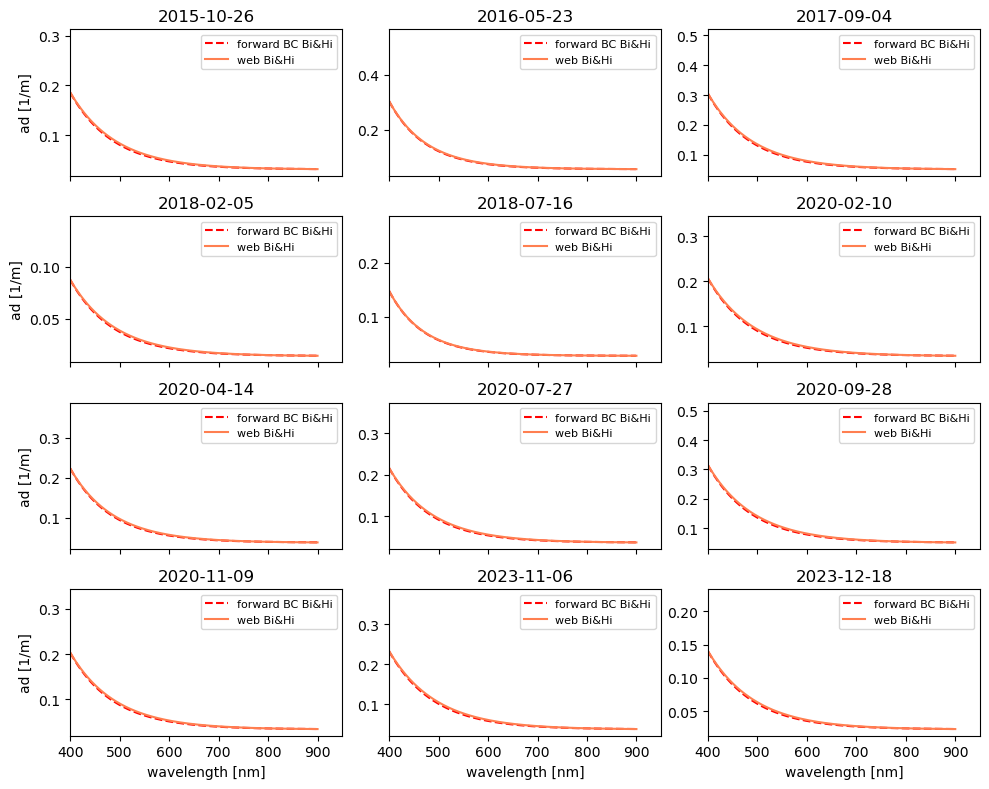

In [136]:
Nx, Ny = (3,4)
# ind = np.sort(np.random.choice(Rrs_momo.index, Nx*Ny, replace=False))
fig, ax=plt.subplots(nrows=Ny, ncols=Nx, figsize=(10,8), sharex=True, sharey=False)

VarList = ['aph','ad','acdom','bph','bd','aw','bw','ap','agp','bp','at','bt','bbph','bbd','bbp','bbw','bbt']
Var = 'ad'

if Var == 'ad' or Var == 'bd':
    anap_spec440 = np.unique(np.round(iop_insitu_sel['anap_spec(440) [m2 g-1]'].values, 5))
    S_xd = np.unique(np.round(iop_insitu_sel['Snap [1/nm]'].values, 5))
    a_md_spec_res = []
    offset_xd = 0.01231
    if len(anap_spec440)==1:
        a_md_spec_res = absorption.a_xd_spec(fw_wl, anap_spec440, S_xd, C_xd = offset_xd, lambda_0=440.)

if Var == 'aph':
    a_i_spec_res = resampling.resample_a_i_spec_EnSADandGold(wavelengths=fw_wl)

if Var == 'bph':
    b_i_spec_res = resampling.resample_b_i_spec_EnSADandGold(wavelengths=fw_wl)


for iy in range(Ny):
    for ix in range(Nx):

        if Var == 'ad':
            thisIOP = absorption.a_d(wavelengths=fw_wl, 
                                     C_ism=iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 
                                     C_phy=iop_insitu_sel['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 
                                     a_md_spec_res= a_md_spec_res
                                    )
        if Var == 'acdom':
            thisIOP = absorption.a_Y(C_Y = iop_insitu_sel['ag(440) [1/m]'].loc[ind[iy*Nx+ix]], 
                                     wavelengths = fw_wl, 
                                     S = iop_insitu_sel['Sg [1/nm]'].loc[ind[iy*Nx+ix]])
        
        if Var == 'aph':
            thisIOP = absorption.a_phy(wavelengths=fw_wl, 
                                       C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_7=0., 
                                       a_i_spec_res=a_i_spec_res)
            thisIOP = absorption.correct_a_phy(a_phy_res=thisIOP, wavelengths=fw_wl, 
                                               C_phy=iop_insitu_sel['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 
                                               interpolate=False)
        if Var == 'bph':
            thisIOP = scattering.b_phy(wavelengths=fw_wl, 
                                       C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]], 
                                       C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]],
                                       C_7=0., 
                                       b_i_spec_res=b_i_spec_res)
            # aphs, thisIOP = IOP_ph_B22_C2(C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]], 
            #                             C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]], 
            #                             C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]], 
            #                             C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]],
            #                             C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]],
            #                             C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]],
            #                             C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]],
            #                             C_7=0., 
            #                             a_i_spec = a_i_spec_res,
            #                             c_i_spec = cphs_i_spec,
            #                             wavelen = fw_wl)
        if Var == 'bd':
            a_d_res = absorption.a_d(wavelengths=fw_wl, 
                                     C_ism=iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 
                                     C_phy=iop_insitu_sel['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 
                                     a_md_spec_res= a_md_spec_res
                                    )
            c_d_res = attenuation.c_d(wavelengths=fw_wl, 
                                  C_phy=iop_insitu_sel['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 
                                  C_ism=iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 
                                  a_md_spec_res=a_md_spec_res)
            thisIOP = c_d_res - a_d_res
        
        ax[iy, ix].plot(fw_wl, thisIOP, 'r--', label='forward BC Bi&Hi')
        
        d = biDict[str(ind[iy*Nx+ix]).split('T')[0]]
        ax[iy, ix].plot(d['wavelen'].values, d[Var].values, '-', color='coral', label='web Bi&Hi')

        # band_resampler = BandResampler(d.wavelen.values, fw_wl) 
        # bi_iop = band_resampler(np.asarray(d[Var].values))
        # ID = fw_wl > 800.
        # perc = np.percentile((bi_iop[ID] - thisIOP[ID])/iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], [5, 50, 95])
        # print("Diff", Var, perc)
        
        # ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0] + ' NAP:' + str(np.round(iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 2)))
        ax[iy, ix].legend(fontsize=8)
        ax[iy, ix].set_xlim((400, 950))
        ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0])
        if Var == 'acdom':
            ax[iy,ix].set_ylim((0,1))
        if iy == Ny-1:
            ax[iy, ix].set_xlabel('wavelength [nm]')
        if ix == 0:
            ax[iy, ix].set_ylabel(Var + ' [1/m]')


fig.tight_layout()
plt.show()

## Attenuation Phytoplankton  
**DO NOT USE!  
It is sufficient to add the offset to the specific absorption of detritus in order to get (almost) identical results with Bi&Hi web-Version!**

In [76]:
path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\consistency\webHEREON\\forPhytoAttenuation\\"
fnames = os.listdir(path)

c_bi_Dict={}
for fn in fnames:
    b = pd.read_csv(path + fn, header=0)
    phyto = fn.split('_')[-1].split('.')[0]
    c_bi_Dict[phyto[:-1]] = b

Brown [0.2220461  0.2307279  0.24704918]
Green [0.22805344 0.22805344 0.22805344]
Crypto [0.19916667 0.19916667 0.19916667]
CyanoB [0.239 0.239 0.239]
CyanoR [0.239 0.239 0.239]
Gold [0.19916667 0.19916667 0.19916667]
Dino [0.2220461  0.2307279  0.24704918]
Case1 [0.12556006 0.15814071 0.23754213]


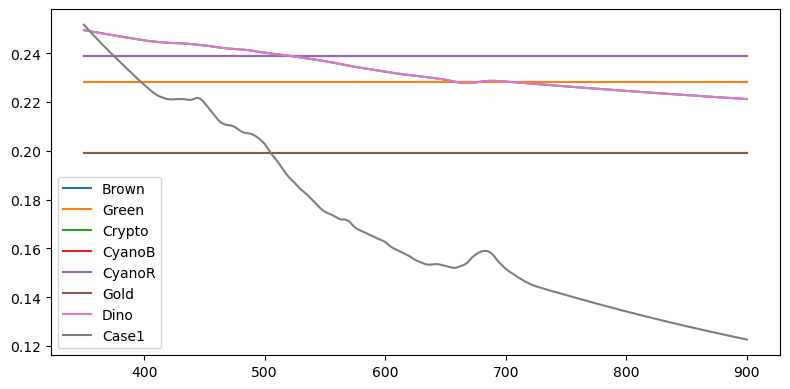

In [86]:
fig, ax = plt.subplots(figsize=(8,4))
# colList = ['Brown', 'Green', 'Crypto', 'CyanoB', 'CyanoR', 'Coccol', 'Case1'] # Bi&Hieronymi web-Version
colList = ['Brown', 'Green', 'Crypto', 'CyanoB', 'CyanoR', 'Gold', 'Dino', 'Case1'] # EnsADGold 
outDF = pd.DataFrame()
for key in colList: #c_bi_Dict.keys():
    key_ = key
    if key == 'Gold':
        key_ = 'Crypto'
    elif key == 'Dino':
        key_ = 'Brown'
    b = c_bi_Dict[key_]
    print(key, np.percentile(b['aph']+b['bph'], [5, 50, 95]))
    ax.plot(b['wavelen'], b['aph']+b['bph'], '-', label=key)
    if len(outDF) == 0:
        outDF['wavelen'] = b['wavelen'].values
    outDF[key] = b['aph'].values+b['bph'].values
ax.legend()
# ax.set_ylim((0.18, 0.28))
fig.tight_layout()
plt.show()

outpath = "C:\\Users\Dagmar\PycharmProjects\\bio_optics\\bio_optics\\data\\"
# outDF.to_csv(outpath + 'c_phy_spec_Bi.txt', header=True, index=False)
outDF.to_csv(outpath + 'c_phy_spec_EnsADGold.txt', header=True, index=False)
## add dinoflagellates -> brown. Goldalgae -> crypto. Setup for the different group sets.

In [117]:
def calc_aph676(Chl, varyA = False):

  A    = 0.0239
  A_sd = 0.1
  A_up = 0.0501
  A_lo = 0.0112
  E    = 0.8938

  if (varyA):
    A = 10 ** rnorm_bound( 1,
      mean = log10(A),
      sd = A_sd,
      up = log10(A_up),
      lo = log10(A_lo)
    )
  
  # split them in two Chl ranges
  r1 = A * Chl**1 # linear Chl <  1
  r2 = A * Chl**E # powerl Chl >= 1
  r = r1
  w = np.array(Chl >= 1)
  r[w] = r2[w]

  # attr(r, "A_aphs676") <- A
  # attr(r, "E_aphs676") <- E
  # attr(r, "varyA") <- varyA

  # class(r) <- "Hereon_aphs_func"

  return r

def generate_aphs(Chl,
                  a_i_spec = [],
                c_i_spec = [],
                 lambda_0_phy = 676.,
                # albedo_ph676=[0.8952, 0.8952, 0.8800, 0.9000, 0.9000, 0.9562, 0.8485], # Bi web-Version
                 albedo_ph676=np.asarray([0.8952, 0.8952, 0.8800, 0.9000, 0.9000,  0.8800, 0.8952, 0.8485]) , # EnsADGold
                  # gamma_ph676=[np.nan, 0.00, 0.00, 0.00, 0.00, np.nan, np.nan] # Bi web-Vserion
                 gamma_ph676=np.asarray([np.nan, 0.00, 0.00, 0.00, 0.00, np.nan, np.nan, np.nan]), # EnsADGold
                 
                  a_frac = np.array([1, 1, 1, 1, 1, 1, 1, 1]),
                wavelengths= np.arange(400., 800.)):

    # Some albedo reference
    # Figure 8 (w532) of Nardelli, Schuyler C., and Michael S. Twardowski. “Assessing the
    # Link between Chlorophyll Concentration and Absorption Line Height at 676 Nm
    # over a Broad Range of Water Types.” Optics Express 24, no. 22 (October 31,
    # 2016): A1374. https://doi.org/10.1364/OE.24.0A1374.
    
    
    # 1. [Chl] -> aphs676
    # 2. [albedo] -> cphs676
    # 3. [Normalized aphs and cphs] -> bphs


    # determine aph676 from the input function
    aph676 = calc_aph676(Chl)

    # if ("Hereon_aphs_func" %in% class(aph676)) {
    #   attr_aph676 <- attributes(aph676)
    # } else {
    #   attr_aph676 <- list(aphs_fun)
    # }
    
    aphs_676_new = aph676 / Chl
    aphs_676_new[Chl == 0] = 1.
    print(aphs_676_new)
    
    aphs_676 = a_i_spec[utils.find_closest(wavelengths, lambda_0_phy)[1]]
    aphs_mat_new = a_i_spec.copy()
    for i in range(aphs_mat_new.shape[1]):
        aphs_mat_new[:, i] = aphs_mat_new[:, i] / aphs_676[i] * aphs_676_new[i]


    cphs_676 = c_i_spec[utils.find_closest(wavelengths, lambda_0_phy)[1]]
    cphs_mat_norm = c_i_spec.copy()
    for i in range(cphs_mat_norm.shape[1]):
        cphs_mat_norm[i,:] /= cphs_676[i]  # normalized at cph676 - shape
    
    # Find group to be changed for the shape
    PG_TBC = [i for i, val in enumerate(gamma_ph676) if not np.isnan(val)]
    for i in PG_TBC:
        cphs_mat_norm[:, i] = (676. / wavelengths) ** gamma_ph676[i]
    
    coef_lin = aphs_676_new / (1. - albedo_ph676) # the coefficients in Eq 16 - magnitude
    cphs_mat_new = cphs_mat_norm.copy()
    for i in range(cphs_mat_new.shape[1]):
        cphs_mat_new[:,i] *= coef_lin[i]
        
    bphs_mat_new = cphs_mat_new - aphs_mat_new
    
    # assumption for reducing cell absorption (e.g. PIC bloom)
    for i in range(cphs_mat_new.shape[1]):
        aphs_mat_new[:, i] *= a_frac[i]
        
    cphs_mat_new <- aphs_mat_new + bphs_mat_new # compensate attenuation back

    return aphs_mat_new, bphs_mat_new, cphs_mat_new

    # aphs <- data.table(wv = phytodive_iop_list$aphs$wv, aphs_mat_new)
    # bphs <- data.table(wv = phytodive_iop_list$bphs$wv, bphs_mat_new)
    # cphs <- data.table(wv = phytodive_iop_list$cphs$wv, cphs_mat_new)
    
    # r <- list(aphs = aphs,
    #         bphs = bphs,
    #         cphs = cphs)
    
    # parm <- list(
    # aph676       =  aph676,
    # albedo_ph676 =  albedo_ph676,
    # gamma_ph676  =  gamma_ph676,
    # vary_cph     =  vary_cph,
    # a_frac       =  a_frac
    # )
    
    # attr(r, "parm") <- parm
    
    # attr(r, "attr_aph676") <- attr_aph676

In [ ]:
def b_ph_web(c_phy_spec, 
             C_0 = 0,
          C_1 = 0,
          C_2 = 0,
          C_3 = 0,
          C_4 = 0,
          C_5 = 0,
          C_6 = 0,
          C_7 = 0,
          a_phy_spec = [], # corrected total a_phy
          aph_i_spec = [],   
          wavelengths = np.arange(400,800),
             lambda_0_phy = 676.,
            # albedo_ph676=[0.8952, 0.8952, 0.8800, 0.9000, 0.9000, 0.9562, 0.8485], # Bi web-Version
             albedo_ph676=[0.8952, 0.8952, 0.8800, 0.9000, 0.9000,  0.8800, 0.8952, 0.8485] , # EnsADGold
              # gamma_ph676=[np.nan, 0.00, 0.00, 0.00, 0.00, np.nan, np.nan] # Bi web-Vserion
             gamma_ph676=[np.nan, 0.00, 0.00, 0.00, 0.00, np.nan, np.nan, np.nan] # EnsADGold
            ):

    C_i = np.array([C_0,C_1,C_2,C_3,C_4,C_5,C_6,C_7])
   
    
    ## web-Version:
    C_sum = np.sum(C_i)
    frac_C = np.zeros(len(C_i))
    if C_sum > 0:
        frac_C = C_i / C_sum
    
    a_phy_res = a_phy_spec / C_sum
    a_phy_lambda_0 = a_phy_res[utils.find_closest(wavelengths, lambda_0_phy)[1]]
    print(a_phy_lambda_0)

    # Determine aph676 from the input function
    # aph676 = aphs_fun(Chl, **kwargs)
    #
    # if hasattr(aph676, '__class__') and "Hereon_aphs_func" in aph676.__class__.__name__:
    #     attr_aph676 = getattr(aph676, '__dict__', {})
    # else:
    #     attr_aph676 = [aphs_fun]
    #
    # aphs_676_new = aph676 / Chl if Chl != 0 else 1
    #
    aphs_mat = aph_i_spec
    aphs_676 = aph_i_spec[utils.find_closest(wavelengths, lambda_0_phy)[1]].values.flatten()
    # aphs_mat_norm = aphs_mat / vec_to_mat(aphs_676, n=aphs_mat.shape[0])
    # aphs_mat_new = aphs_mat_norm * aphs_676_new

    # cphs_mat = c_phy_spec.iloc[:, 1:].to_numpy()
    ID_676 = utils.find_closest(wavelengths, lambda_0_phy)[1] # or closest to 676!
    cphs_676 = c_phy_spec[ID_676,:].flatten()
    cphs_mat_norm = c_phy_spec.copy()
    for i in range(cphs_mat_norm.shape[1]): cphs_mat_norm[:, i] /= cphs_676[i]

    PG_TBC = [i for i, val in enumerate(gamma_ph676) if not np.isnan(val)]
    for i in PG_TBC:
        cphs_mat_norm[:, i] = (676. / wavelengths) ** gamma_ph676[i]

    coef_lin = a_phy_lambda_0 / (1 - np.array(albedo_ph676))
    cphs_mat_new = cphs_mat_norm * vec_to_mat(coef_lin, n=cphs_mat.shape[0], by=1)
    bphs_mat_new = cphs_mat_new - aphs_mat_new

    aphs_mat_new = aphs_mat_new * vec_to_mat(a_frac, n=aphs_mat_new.shape[0], by=1)
    cphs_mat_new = aphs_mat_new + bphs_mat_new

    bphs = pd.DataFrame(np.column_stack((phytodive_iop_list['bphs']['wv'], bphs_mat_new)),
                        columns=phytodive_iop_list['bphs'].columns)


    return r

[3.468e+00 3.700e-02 3.310e-01 4.200e-02 0.000e+00 6.400e-02 1.000e-03
 0.000e+00]
[0.02094333 0.0239     0.0239     0.0239     1.         0.0239
 0.0239     1.        ]


C:\Users\Dagmar\AppData\Local\Temp\ipykernel_23152\3577271456.py:65: RuntimeWarning: invalid value encountered in divide
  aphs_676_new = aph676 / Chl


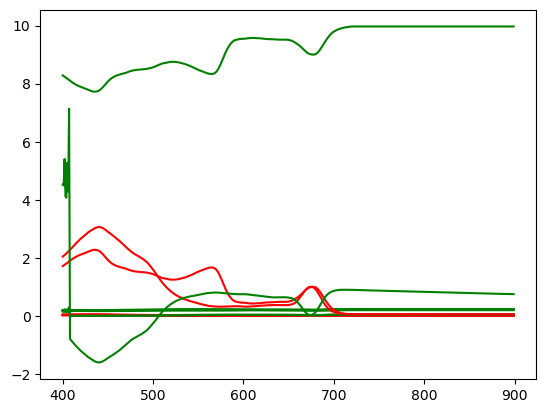

In [119]:
outpath = "C:\\Users\Dagmar\PycharmProjects\\bio_optics\\bio_optics\\data\\"
cphs = pd.read_csv(outpath + 'c_phy_spec_EnsADGold.txt', header=0)
# resample
band_resampler = BandResampler(cphs.wavelen.values, fw_wl) 
cphs_i_spec = band_resampler(np.asarray(cphs.values)[:,1:])

iy = 0
ix = 0
C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]]
C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]] 
C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]] 
C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]]
C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]]
C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]]
C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]]
C_7=0.
C_i = np.array([C_0,C_1,C_2,C_3,C_4,C_5,C_6,C_7])
print(np.round(C_i, 3))

aph, bph = IOP_ph_B22_C2(C_0=iop_insitu_sel['Ckie [µg/l]'].loc[ind[iy*Nx+ix]], 
                           C_1=iop_insitu_sel['Cgr [µg/l]'].loc[ind[iy*Nx+ix]], 
                           C_2=iop_insitu_sel['Ccry [µg/l]'].loc[ind[iy*Nx+ix]], 
                           C_3=iop_insitu_sel['Cbl [µg/l]'].loc[ind[iy*Nx+ix]],
                           C_4=iop_insitu_sel['Cbl2 [µg/l]'].loc[ind[iy*Nx+ix]],
                           C_5=iop_insitu_sel['Cgold [µg/l]'].loc[ind[iy*Nx+ix]],
                           C_6=iop_insitu_sel['Cdino [µg/l]'].loc[ind[iy*Nx+ix]],
                           C_7=0., 
                  a_i_spec = a_i_spec_res,
                c_i_spec = cphs_i_spec,
          wavelen = fw_wl)


array([[0.03394696, 0.02421818, 0.02673526, ..., 0.02978678, 0.055971  ,
        0.04884668],
       [0.03431994, 0.02440274, 0.02697784, ..., 0.03010771, 0.055975  ,
        0.04944208],
       [0.03469291, 0.0245873 , 0.02722042, ..., 0.03042864, 0.055979  ,
        0.05003748],
       ...,
       [0.00086618, 0.00094715, 0.00087481, ..., 0.00017514, 0.        ,
        0.0014334 ],
       [0.00086618, 0.00094715, 0.00087481, ..., 0.00017514, 0.        ,
        0.0014334 ],
       [0.00086618, 0.00094715, 0.00087481, ..., 0.00017514, 0.        ,
        0.0014334 ]])

In [113]:
def IOP_ph_B22_C2(C_0 = 0,
          C_1 = 0,
          C_2 = 0,
          C_3 = 0,
          C_4 = 0,
          C_5 = 0,
          C_6 = 0,
          C_7 = 0,
                  a_i_spec = [],
                c_i_spec = [],
          wavelen = np.arange(400., 800.)):

    C_i = np.array([C_0,C_1,C_2,C_3,C_4,C_5,C_6,C_7])
    Chl_sum = np.sum(C_i)
    frac_phyto = C_i / Chl_sum
    
    aphs, bphs, cphs = generate_aphs(C_i, a_i_spec = a_i_spec,
                c_i_spec = c_i_spec, wavelengths = wavelen)

    for i in range(aphs.shape[1]):
        plt.plot(wavelen, aphs[:, i], 'r-')
        plt.plot(wavelen, bphs[:, i], 'g-')
    plt.show()
    
    aphs_ = aphs.copy()
    bphs_ = bphs.copy()
    for i in range(aphs.shape[1]):
        aphs_ *= frac_phyto[i]
        bphs_ *= frac_phyto[i]
    
    aphs_sum = np.sum(aphs_, axis=1)
    bphs_sum = np.sum(bphs_, axis=1)
    cphs_sum = aphs_sum + bphs_sum
    
    aph = Chl_sum * aphs_sum
    bph = Chl_sum * bphs_sum
    cph = Chl_sum * cphs_sum
    return aph, bph

# Forward Bi&Hi + CHIME convolve and noise  
Simulations with the Bi&Hi BC implementation are used to setup Rrs spectra.  
**Features:**  
- no fluoresence
- specific absorption a_d with offset (like web-Version Bi&Hi)
- single observation / sun geometry (how is this solved in WASI? There are adjustments for more angles...)
  
**New:**  
found the updated Lee et al 2011 G implementation! Yu, Lee et al 2022  
https://github.com/oceanopticsxmu/osaw/blob/main/get_G.m etc.  
**Quote:** "G0w(Ω), G1w(Ω), G0p(Ω), and G1p(Ω),
collectively termed G, are model coefficients that are dependent on
angular geometry and assumed to be independent of IOPs and wavelength
(Lee et al., 2011). The values of G can be retrieved from a look-uptable
(LUT), termed G-LUT, for given angular geometry. Although a GLUT
was provided in Lee et al. (2011), we updated this LUT following
the same approach in Lee et al. (2011) by expanding viewing angles and
seawater IOPs using the simulated dataset in this study (described in
Section 2.2). Specifically, G-LUT in Lee et al. (2011) excludes scenarios
with *large viewing- and solar-zenith angles (i.e., θv > 70◦ and θs > 75◦)*,
which need to be expanded for more accurate estimation of αw(λ),
although Rrs(λ) of extremely large angles contribute much less to αw(λ)
due to the cosine weighting. Also, the dataset of this study includes *more
optically complex waters*, thus the resultant G-LUT could have broader
applicability."

## Dev: Angle dependency Yu et al 2022 (updates Lee et al. 2011)  
time efficient way to interpolate along the three dimensions: xarray and interp

### Example 1

In [178]:
import scipy.io
mat = scipy.io.loadmat("../water/G_LUT.mat")
G_LUT = mat['G_LUT']

## setup matrix LUT ##
# input: sun zenith angle
isza = 30. # sun zenith angle

solz=np.asarray([0,15,30,45,60,75,80,88])  # solor zenith angle steps in LUT
# % [~,sidx]=min(abs(solz-isza));
# % isza=solz(sidx);
sidx= np.where(solz-isza>=0)[0]
if isza==0:
    isza1=solz[sidx][0]
else:
    isza1=solz[sidx[0]-1]
    
isza2=solz[sidx[0]]

print(isza1, isza2)

senz= np.asarray([0,10,20,30,40,50,60,70,80,87.5])
phi= np.asarray([0,15,30,45,60,75,90,105,120,135,150,165,180])
ntheta=len(senz)
nphi=len(phi)
G0 = np.zeros((ntheta,nphi,4))
G1 = np.zeros((ntheta,nphi,4))
G2 = np.zeros((ntheta,nphi,4))

for i in range(ntheta):
    for j in range(nphi):
        if i==0:
            G1[i,j,:4] = G_LUT[0, 3:]   
            G2[i,j,:4] = G_LUT[0, 3:]  
        else:
            ivza=senz[i]
            ivaa=phi[j] 
            idx1= np.where(G_LUT[:, 0]==isza1)[0]
            idx2= np.where(G_LUT[:, 1]==ivza)[0]
            idx3= np.where(G_LUT[:, 2]==ivaa)[0]
            idx_temp= np.intersect1d(idx1,idx2)
            idx = np.intersect1d(idx_temp,idx3)
            G1[i,j,:4] = G_LUT[idx, 3:]  #squeeze(
            
            idx11=np.where(G_LUT[:,0]==isza2)[0]
            idx_temp2= np.intersect1d(idx11,idx2)
            idx_3= np.intersect1d(idx_temp2,idx3)
            G2[i,j,:4]= G_LUT[idx_3,3:] #squeeze(

if isza==0:
    G0 = G1
else:
    G0=(isza2-isza)/(isza2-isza1)*G1 + (isza-isza1)/(isza2-isza1)*G2
# return G0

15 30


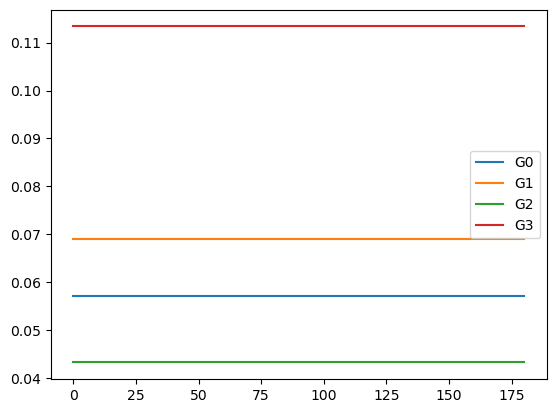

In [194]:
# default values in inversion! Lee et al 2011
# Gw0 = 0.05881474,
# Gw1 = 0.05062697,
# Gp0 = 0.03997009,
# Gp1 = 0.1398902
# solar zenith angle = 30° and nadir viewing direction being Gw0 = 0.05881474, Gw1 = 0.05062697, Gp0 = 0.03997009, and Gp1 = 0.1398902


input_senz = 0.
#input_aa = 0.
G_out = np.zeros((len(phi), 4))
for i, input_aa in enumerate(phi):
    id_senz = np.where(senz-input_senz == 0)[0]
    id_aa = np.where(phi-input_aa == 0)[0]
    G_out[i, :] = G0[id_senz, id_aa, :]

for i in range(4):
    plt.plot(phi, G_out[:, i], '-', label='G'+str(i))
plt.legend()
plt.show()

In [202]:
input_senz = 0.
input_aa = 0.
id_senz = np.where(senz-input_senz == 0)[0]
id_aa = np.where(phi-input_aa == 0)[0]
G_out = G0[id_senz, id_aa, :][0]
G_out

array([0.05703582, 0.06903192, 0.04320829, 0.11338117])

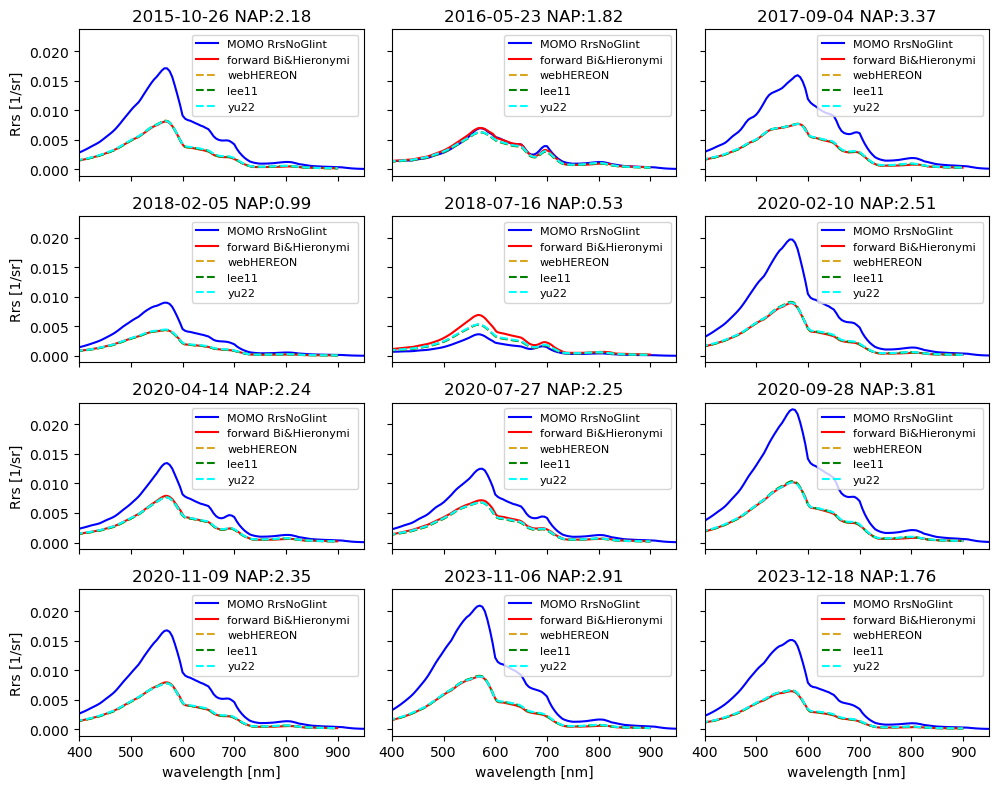

In [203]:
Nx, Ny = (3,4)
# ind = np.sort(np.random.choice(Rrs_momo.index, Nx*Ny, replace=False))
fig, ax=plt.subplots(nrows=Ny, ncols=Nx, figsize=(10,8), sharex=True, sharey=True)

for iy in range(Ny):
    for ix in range(Nx):
        ax[iy, ix].plot(wl, Rrs_momo.loc[ind[iy*Nx+ix],:].values, 'b-', label='MOMO '+ RrsType)
        # ax[iy, ix].plot(wl, Rrs_noglint_sel.iloc[iy*Nx+ix,:].values, '-', color='lightblue', label='MOMO '+ RrsType)
        
        ax[iy, ix].plot(fw_wl, fw_sel.loc[ind[iy*Nx+ix],:].values, 'r-', label='forward Bi&Hieronymi ')
        d = biDict[str(ind[iy*Nx+ix]).split('T')[0]]
        # print(d.columns.values)
        bh_lee11 = lee.R_rs_deep(a = d['at'] , b_b= d['bbt'], b_bp= d['bbp'], b_bw= d['bbw'], Gw0 = 0.05881474, Gw1 = 0.05062697, Gp0 = 0.03997009, Gp1 = 0.1398902)
        bh_yu22 = lee.R_rs_deep(a = d['at'] , b_b= d['bbt'], b_bp= d['bbp'], b_bw= d['bbw'], Gw0 = G_out[0], Gw1 = G_out[1], Gp0 = G_out[2], Gp1 = G_out[3])
        ax[iy, ix].plot(d['wavelen'].values, d['Rrs_L11'].values, '--', color='goldenrod', label='webHEREON')
        ax[iy, ix].plot(d['wavelen'].values, bh_lee11, '--', color='green', label='lee11')
        ax[iy, ix].plot(d['wavelen'].values, bh_yu22, '--', color='aqua', label='yu22')
        
        ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0] + ' NAP:' + str(np.round(iop_insitu_sel['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 2)))
        ax[iy, ix].legend(fontsize=8)
        ax[iy, ix].set_xlim((400, 950))
        if iy == Ny-1:
            ax[iy, ix].set_xlabel('wavelength [nm]')
        if ix == 0:
            ax[iy, ix].set_ylabel('Rrs [1/sr]')


fig.tight_layout()
plt.show()

### Generalised Geometry parameter handling

In [215]:
import scipy.io
mat = scipy.io.loadmat("../water/G_LUT.mat")
G_LUT = mat['G_LUT']

# solz=np.asarray([0.,15,30,45,60,75,80,88])  # solar zenith angle steps in LUT, column 0
# senz= np.asarray([0,10,20,30,40,50,60,70,80,87.5]) # sensor zenith angle steps in LUT, column 1
# phi= np.asarray([0.,15,30,45,60,75,90,105,120,135,150,165,180]) # azimuth difference angle steps in LUT, column 2

## setup xarray instance with coordinates (solz, senz, phi)
G_df = pd.DataFrame(G_LUT, columns=['solz', 'senz', 'phi', 'G0w', 'G1w', 'G0p', 'G1p'])
# G_df.to_csv("../water/G_LUT.csv", index=False)

solz = np.unique(G_df.iloc[:,0])
senz = np.unique(G_df.iloc[:,1])
phi = np.unique(G_df.iloc[:,2])

In [226]:

G0w = np.zeros((len(solz), len(senz), len(phi))) + np.nan
for i, sz in enumerate(solz):
    for j, oz in enumerate(senz):
        for k, aa in enumerate(phi):
            if oz == 0:
                id_solz = np.where( G_LUT[:, 0] == sz)[0]
                id_senz = np.where( G_LUT[:, 1] == oz)[0]
                id_aa = np.where( G_LUT[:, 2] == 0)[0]
                idx_temp= np.intersect1d(id_solz, id_senz)
                idx = np.intersect1d(idx_temp,id_aa)
            else:
                id_solz = np.where( G_LUT[:, 0] == sz)[0]
                id_senz = np.where( G_LUT[:, 1] == oz)[0]
                id_aa = np.where( G_LUT[:, 2] == aa)[0]
                idx_temp= np.intersect1d(id_solz, id_senz)
                idx = np.intersect1d(idx_temp,id_aa)
            # print(i, j, k, idx)
            if len(idx) ==1:
                G0w[i, j, k] = G_LUT[idx, 3] 

import xarray as xr
da = xr.DataArray(
    data=G0w,
    dims=["solz", "senz", "phi"],
    coords=dict(
        solz=solz,
        senz=senz,
        phi=phi))
da


C:\Users\Dagmar\AppData\Local\Temp\ipykernel_23152\2911245904.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  G0w[i, j, k] = G_LUT[idx, 3]


<xarray.DataArray (solz: 8, senz: 10, phi: 13)> Size: 8kB
array([[[0.05703582, 0.05703582, 0.05703582, ..., 0.05703582,
         0.05703582, 0.05703582],
        [0.05651874, 0.05644266, 0.05634419, ..., 0.05634419,
         0.05644265, 0.05651874],
        [0.05488212, 0.05488929, 0.05474718, ..., 0.05474717,
         0.05488929, 0.05488212],
        ...,
        [0.04020132, 0.04025784, 0.04018637, ..., 0.04018636,
         0.04025784, 0.04020132],
        [0.03526034, 0.03500906, 0.03466719, ..., 0.03466719,
         0.03500905, 0.03526034],
        [0.03000681, 0.0292391 , 0.02973967, ..., 0.02973967,
         0.02923295, 0.03000681]],

       [[0.05489909, 0.05489909, 0.05489909, ..., 0.05489909,
         0.05489909, 0.05489909],
        [0.05790389, 0.05771994, 0.05726018, ..., 0.0518139 ,
         0.05165272, 0.05164553],
        [0.05860166, 0.05839626, 0.05762965, ..., 0.04905609,
         0.04881653, 0.04867718],
...
        [0.04907402, 0.04839639, 0.04626699, ..., 0.02142186,
         0.02030261, 0.01989414],
        [0.04498846, 0.0439384 , 0.04150971, ..., 0.01809308,
         0.01729867, 0.01713792],
        [0.03961565, 0.03794988, 0.03682294, ..., 0.01616645,
         0.0153469 , 0.01550986]],

       [[0.04503721, 0.04503721, 0.04503721, ..., 0.04503721,
         0.04503721, 0.04503721],
        [0.04659358, 0.04647526, 0.04622433, ..., 0.04356895,
         0.04351332, 0.04351804],
        [0.04713066, 0.04701996, 0.04657095, ..., 0.04203122,
         0.04192725, 0.04183692],
        ...,
        [0.0425978 , 0.04224655, 0.04104815, ..., 0.03076058,
         0.03076607, 0.03071839],
        [0.03851094, 0.03783212, 0.03637223, ..., 0.02748364,
         0.02797252, 0.02827929],
        [0.03367259, 0.03246916, 0.03205393, ..., 0.02515196,
         0.02524274, 0.02608602]]])
Coordinates:
  * solz     (solz) float64 64B 0.0 15.0 30.0 45.0 60.0 75.0 80.0 88.0
  * senz     (senz) float64 80B 0.0 10.0 20.0 30.0 40.0 50.0 60.0 70.0 80.0 87.5
  * phi      (phi) float64 104B 0.0 15.0 30.0 45.0 ... 135.0 150.0 165.0 180.0

In [233]:
solz_ = np.array((30., 32.5))
senz_ = np.array((0., 12.5))
phi_ = np.array((160., 180.))
for i in range(len(solz_)):
    print(da.interp(solz=[solz_[i]], senz=[senz_[i]], phi=[phi_[i]], method="linear").values.flatten())

[0.05285899]
[0.04721596]


### Use generalised implementation 

In [238]:
G_df, solz, senz, phi = lee.read_G_LUT()

In [239]:
xG0w = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G0w')
xG1w = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G1w')
xG0p = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G0p')
xG1p = lee.setup_xarray_Gx(G_df, solz, senz, phi, varname='G1p')

In [240]:
from suncalc import get_position, get_times
from datetime import datetime

In [243]:
insitu.shape

(3074, 35)

In [247]:
# muggelsee: lat: 52.4373  lon: 13.6474
sun_dict = get_position(insitu.datetime, lng= 13.6474, lat=52.4373)
sun_dict['zenith'] = (np.pi/2. - sun_dict['altitude'])*180./np.pi
sun_dict

{'azimuth': array([0.20200017, 0.20043717, 0.19891799, ..., 0.24191226, 0.23981661,
        0.23773026]),
 'altitude': array([0.24732955, 0.24954218, 0.25187763, ..., 0.23009098, 0.22965242,
        0.22934732]),
 'zenith': array([75.82906076, 75.70228645, 75.56847497, ..., 76.81675777,
        76.84188568, 76.85936651])}

In [274]:
G = np.zeros((insitu.shape[0], 4))
senz, phi = (50., 135.) # (30., 135.) # (0,0)
G[:, 0] = xG0w.interp(solz=sun_dict['zenith'], senz=senz, phi=phi, method="linear").values.flatten()
G[:, 1] = xG1w.interp(solz=sun_dict['zenith'], senz=senz, phi=phi, method="linear").values.flatten()
G[:, 2] = xG0p.interp(solz=sun_dict['zenith'], senz=senz, phi=phi, method="linear").values.flatten()
G[:, 3] = xG1p.interp(solz=sun_dict['zenith'], senz=senz, phi=phi, method="linear").values.flatten()

In [275]:
insitu['G0w'] = G[:, 0]
insitu['G1w'] = G[:, 1]
insitu['G0p'] = G[:, 2]
insitu['G1p'] = G[:, 3]
insitu['SZA'] = sun_dict['zenith']
insitu['OZA'] = senz
insitu['dAA'] = phi

# inputPath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\"
# metaDict = {'helsinki_ss': {'folder': 'Helsinki\\input_simulations' , 'fileName':  'helsinki_silja_serenade_IOP_v0.1b.csv'}, # helsinki_silja_serenade_daily_v0.3.cvs
#          'helsinki_fm': {'folder': 'Helsinki\\input_simulations', 'fileName': 'helsinki_finnmaid_daily_v0.3.csv'}, 
#         'berlin_muggelsee': {'folder': 'Muggelsee - Berlin\\input_simulations' , 'fileName': 'berlin_muggelsee_IOP_daily_v0.3.csv'}, 
#        }
print(position)
folder = metaDict[position]['folder']
fname = metaDict[position]['fileName']
outpath = inputPath + folder+ "\\" + fname.split('.csv')[0]+ "_OZA2.csv"
print(outpath)
insitu.to_csv(outpath, header=True, index=False)

berlin_muggelsee
Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Muggelsee - Berlin\input_simulations\berlin_muggelsee_IOP_daily_v0.3_SZA_Gx_OZA2.csv


### Check Coefficients against Pitarch 2025 plots  
**Azimuth angle difference**: it seems the definition is somewhat different or values have been stored strangely/wrongly in the LUT!  
To be consistent with the Pitarch paper, my dphi-values have to be transformed by *d_phi = 180°- d_phi_LUT (d_phi_LUT = 180° - d_phi)*


In [282]:
solz

array([ 0., 15., 30., 45., 60., 75., 80., 88.])

In [299]:
senz, phi = (0,0)
G = np.zeros((len(solz), 4))
G[:, 0] = xG0w.interp(solz=solz, senz=senz, phi=180.-phi, method="linear").values.flatten()
G[:, 1] = xG1w.interp(solz=solz, senz=senz, phi=180.-phi, method="linear").values.flatten()
G[:, 2] = xG0p.interp(solz=solz, senz=senz, phi=180.-phi, method="linear").values.flatten()
G[:, 3] = xG1p.interp(solz=solz, senz=senz, phi=180.-phi, method="linear").values.flatten()

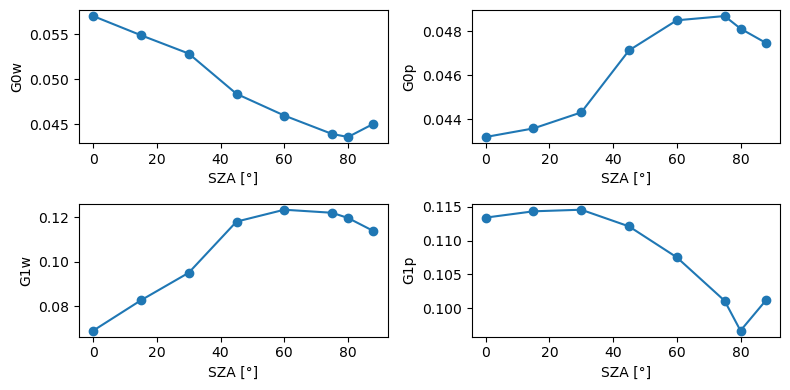

In [298]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,4))
varList = ['G0w', 'G1w', 'G0p', 'G1p']
for ix in range(2):
    for iy in range(2):
        ax[iy, ix].plot(solz, G[:,iy +ix*2], 'o-')
        ax[iy, ix].set_ylabel(varList[iy + ix*2])
        ax[iy, ix].set_xlabel('SZA [°]')
fig.tight_layout()
plt.show()

In [295]:
phi_= np.arange(0, 181, 20)
phi_LUT = 180. - phi_
G = np.zeros((len(phi_), 4))
G[:, 0] = xG0w.interp(solz=60, senz=60, phi=phi_LUT, method="linear").values.flatten()
G[:, 1] = xG1w.interp(solz=60, senz=60, phi=phi_LUT, method="linear").values.flatten()
G[:, 2] = xG0p.interp(solz=60, senz=60, phi=phi_LUT, method="linear").values.flatten()
G[:, 3] = xG1p.interp(solz=60, senz=60, phi=phi_LUT, method="linear").values.flatten()

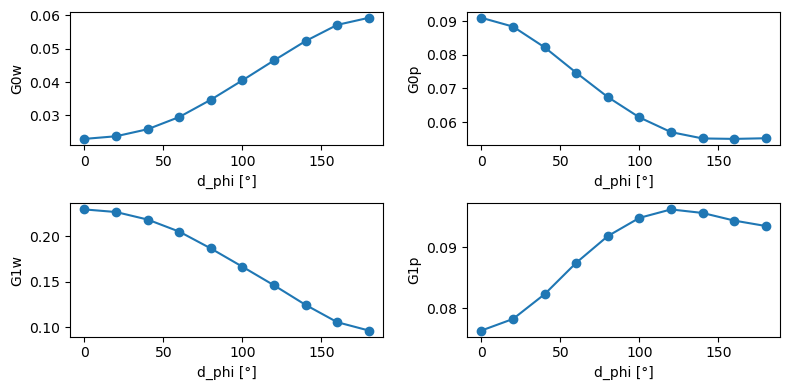

In [296]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,4))
varList = ['G0w', 'G1w', 'G0p', 'G1p']
for ix in range(2):
    for iy in range(2):
        ax[iy, ix].plot(phi_, G[:,iy +ix*2], 'o-')
        ax[iy, ix].set_ylabel(varList[iy + ix*2])
        ax[iy, ix].set_xlabel('d_phi [°]')
fig.tight_layout()
plt.show()

# Analyse Systematic difference: MOMO & Forward BC Bi&Hi  
Simulations with the Bi&Hi BC implementation are used to setup Rrs spectra.  
**Features:**  
- no fluoresence
- specific absorption a_d with offset (like web-Version Bi&Hi)
- sun geometry from Yu et al 2022
  
**Data sets / versions**
- with angle dependency (SZA variable, VZA=0°)
- static angles (SZA=30°, VZA=0°)
- MOMO (corrected: Rrs = Lr / (Ed diffuse + Ed direct)
- additional: input to simulations

In [130]:
regionName = 'helsinki_silja_serenade' #'muggelsee' 

### IOP input

In [153]:
## IOP Input to simulations
inputPath = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\"
metaDict = {'helsinki_silja_serenade': {'folder': 'Helsinki\\input_simulations' , 'fileName': 'helsinki_silja_serenade_IOP_v0.2.csv' }, # helsinki_silja_serenade_daily_v0.3.cvs #'helsinki_silja_serenade_IOP_v0.1b.csv'
         'helsinki_fm': {'folder': 'Helsinki\\input_simulations', 'fileName': 'helsinki_finnmaid_daily_v0.3.csv'}, 
        'muggelsee': {'folder': 'Muggelsee - Berlin\\input_simulations' ,  'fileName': 'berlin_muggelsee_IOP_daily_v0.3.csv'}, # 'fileName': 'berlin_muggelsee_IOP_daily_v0.3_SZA_Gx.csv'
       }

folder = metaDict[regionName]['folder']
fname = metaDict[regionName]['fileName']

insitu = pd.read_csv(inputPath + folder + '\\'+ fname)
timeList = ['date', 'datetime', 'valid_time', 'DATE']
timeVarname = [a for a in timeList if a in insitu.columns.values]
print(timeVarname)
# ## helsinki_ss: drop 2023-10-10!
# ID = insitu[timeVarname[0]].values == '2024-10-10'
# print(np.sum(ID))
timeTest = np.asarray([str(t).split(' ')[0] for t in insitu[timeVarname[0]].values])
print(insitu[timeVarname].iloc[:10])
insitu['date'] = pd.to_datetime(timeTest) #.dt.tz_localize(timezone).dt.tz_convert("UTC")
insitu = insitu.set_index('date')
# insitu.columns.values
insitu

['date']
         date
0  2023-02-26
1  2023-03-04
2  2023-03-06
3  2023-03-08
4  2023-03-10
5  2023-03-12
6  2023-03-14
7  2023-03-16
8  2023-03-18
9  2023-05-17


,Temp °C,Sal psu,Chlg [µg/l],Cgr [µg/l],Ckie [µg/l],Cbl [µg/l],Ccry [µg/l],Cgold [µg/l],Cdino [µg/l],ag(440) [1/m],...,omaod550,ssaod550,aod469,aod550,aod670,aod865,aod1240,tc_ch4,gtco3,tcwv
date,,,,,,,,,,,,,,,,,,,,,
2023-02-26,1.070950,5.571118,2.180666,0.0,2.180666,0.0,0.0,0.0,0.0,0.188068,...,0.008684,0.002333,0.017800,0.014673,0.011431,0.008149,0.005232,0.010022,0.008339,3.949168
2023-03-04,1.062421,5.476938,2.239048,0.0,2.239048,0.0,0.0,0.0,0.0,0.219607,...,0.032336,0.034230,0.089230,0.078934,0.068079,0.056606,0.045382,0.009892,0.010064,6.373599
2023-03-06,0.951621,5.373000,2.305856,0.0,2.305856,0.0,0.0,0.0,0.0,0.254793,...,0.020753,0.009193,0.056821,0.048059,0.038582,0.028552,0.018892,0.009948,0.009708,4.808395
2023-03-08,0.822049,5.606765,2.469566,0.0,2.469566,0.0,0.0,0.0,0.0,0.176205,...,0.034397,0.008206,0.069136,0.057731,0.045602,0.032884,0.020841,0.009755,0.010608,5.642628
2023-03-10,0.586843,5.530875,2.264627,0.0,2.264627,0.0,0.0,0.0,0.0,0.201487,...,0.001478,0.000560,0.003803,0.003143,0.002459,0.001771,0.001159,0.010008,0.010209,3.529203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,4.902594,5.718895,2.745602,0.0,2.745602,0.0,0.0,0.0,0.0,0.139366,...,0.024295,0.022941,0.115169,0.105271,0.094862,0.085157,0.070297,0.010147,0.005446,25.457520
2024-12-15,3.578357,5.815412,2.058049,0.0,2.058049,0.0,0.0,0.0,0.0,0.107540,...,0.008429,0.001207,0.016596,0.013599,0.010450,0.007215,0.004271,0.010153,0.006149,5.189776
2024-12-15,3.118688,5.564667,2.519916,0.0,2.519916,0.0,0.0,0.0,0.0,0.190855,...,0.008429,0.001207,0.016596,0.013599,0.010450,0.007215,0.004271,0.010153,0.006149,5.189776


### Forward BC Bi&Hieronymi - variable SZA

In [154]:
## SZA dependent
spath = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward_withSZA\\"
fnames = os.listdir(spath)
# print(fnames)
fnames = [fn for fn in fnames if regionName in fn]
if 'daily' in fname:
    fnames = [fn for fn in fnames if 'daily' in fn]
else:
    fnames = [fn for fn in fnames if not 'daily' in fn]
print(fnames)
fw_sza = pd.read_csv(spath + fnames[0], header=0, sep='\t')
fw_sza = fw_sza.set_index(insitu.index)
fw_sza

['SimRrs_InsituForward_HEREON_helsinki_silja_serenade_IOP_v0_Inv0.1_AngleDepSZA.txt']


,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,890.0,891.0,892.0,893.0,894.0,895.0,896.0,897.0,898.0,899.0
date,,,,,,,,,,,,,,,,,,,,,
2023-02-26,0.003653,0.003705,0.003757,0.003810,0.003863,0.003916,0.003970,0.004024,0.004078,0.004133,...,0.000492,0.000487,0.000483,0.000478,0.000473,0.000469,0.000464,0.000460,0.000456,0.000451
2023-03-04,0.003409,0.003459,0.003510,0.003561,0.003612,0.003663,0.003715,0.003767,0.003819,0.003872,...,0.000493,0.000488,0.000483,0.000479,0.000474,0.000470,0.000465,0.000461,0.000456,0.000452
2023-03-06,0.002969,0.003014,0.003060,0.003106,0.003152,0.003198,0.003245,0.003292,0.003340,0.003388,...,0.000438,0.000434,0.000429,0.000425,0.000421,0.000417,0.000413,0.000409,0.000405,0.000402
2023-03-08,0.003462,0.003510,0.003559,0.003609,0.003658,0.003708,0.003758,0.003808,0.003858,0.003909,...,0.000422,0.000418,0.000413,0.000409,0.000405,0.000402,0.000398,0.000394,0.000390,0.000387
2023-03-10,0.003367,0.003416,0.003466,0.003515,0.003565,0.003616,0.003666,0.003717,0.003768,0.003820,...,0.000445,0.000441,0.000436,0.000432,0.000428,0.000424,0.000420,0.000416,0.000412,0.000408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,0.004449,0.004505,0.004562,0.004618,0.004675,0.004732,0.004789,0.004847,0.004905,0.004963,...,0.000645,0.000639,0.000633,0.000626,0.000620,0.000615,0.000609,0.000603,0.000597,0.000592
2024-12-15,0.004824,0.004884,0.004944,0.005005,0.005065,0.005126,0.005187,0.005249,0.005310,0.005372,...,0.000627,0.000621,0.000615,0.000609,0.000603,0.000597,0.000591,0.000586,0.000580,0.000575
2024-12-15,0.004046,0.004101,0.004157,0.004212,0.004268,0.004325,0.004381,0.004439,0.004496,0.004554,...,0.000654,0.000647,0.000641,0.000635,0.000628,0.000622,0.000617,0.000611,0.000605,0.000599


### Forward BC Bi&Hieronymi - static angles

In [156]:
## static SZA=30°
path = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
fnames = os.listdir(path)
fnames = [fn for fn in fnames if regionName in fn and fn.startswith('SimRrs')]
# if regionName == 'helsinki_silja_serenade':
#     fnames = [fn for fn in fnames if 'Inv0.4.' in fn]
if 'daily' in fname:
    fnames = [fn for fn in fnames if 'daily' in fn]
else:
    fnames = [fn for fn in fnames if not 'daily' in fn]
print(fnames)
fw_stat = pd.read_csv(path + fnames[0], header=0, sep='\t')
fw_stat = fw_stat.set_index(insitu.index)
fw_wl = np.asarray([float(a) for a in fw_stat.columns.values])
fw_stat


['SimRrs_InsituForward_HEREON_helsinki_silja_serenade_IOP_v0_Inv0.1.txt']


,400.0,401.0,402.0,403.0,404.0,405.0,406.0,407.0,408.0,409.0,...,890.0,891.0,892.0,893.0,894.0,895.0,896.0,897.0,898.0,899.0
date,,,,,,,,,,,,,,,,,,,,,
2023-02-26,0.003301,0.003350,0.003399,0.003449,0.003499,0.003549,0.003599,0.003651,0.003702,0.003754,...,0.000410,0.000406,0.000402,0.000398,0.000394,0.000391,0.000387,0.000383,0.000380,0.000376
2023-03-04,0.003068,0.003114,0.003161,0.003209,0.003257,0.003305,0.003353,0.003402,0.003452,0.003501,...,0.000411,0.000407,0.000403,0.000399,0.000395,0.000391,0.000388,0.000384,0.000380,0.000377
2023-03-06,0.002660,0.002701,0.002743,0.002786,0.002828,0.002871,0.002915,0.002959,0.003003,0.003048,...,0.000365,0.000361,0.000358,0.000354,0.000351,0.000347,0.000344,0.000341,0.000338,0.000334
2023-03-08,0.003124,0.003169,0.003215,0.003261,0.003307,0.003354,0.003401,0.003448,0.003495,0.003543,...,0.000351,0.000348,0.000344,0.000341,0.000338,0.000334,0.000331,0.000328,0.000325,0.000322
2023-03-10,0.003031,0.003077,0.003123,0.003169,0.003216,0.003262,0.003310,0.003357,0.003406,0.003454,...,0.000371,0.000367,0.000364,0.000360,0.000357,0.000353,0.000350,0.000346,0.000343,0.000340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,0.004134,0.004189,0.004244,0.004300,0.004356,0.004412,0.004468,0.004524,0.004581,0.004639,...,0.000550,0.000545,0.000539,0.000534,0.000529,0.000523,0.000518,0.000514,0.000509,0.000504
2024-12-15,0.004511,0.004570,0.004629,0.004689,0.004749,0.004809,0.004870,0.004930,0.004992,0.005053,...,0.000536,0.000531,0.000525,0.000520,0.000515,0.000510,0.000505,0.000500,0.000496,0.000491
2024-12-15,0.003742,0.003795,0.003849,0.003904,0.003958,0.004013,0.004068,0.004124,0.004180,0.004237,...,0.000559,0.000553,0.000548,0.000542,0.000537,0.000532,0.000527,0.000522,0.000517,0.000512


### MOMO corrected Rrs

In [167]:
## MOMO corrected    
## Simulated spectra MOMO Rrs
# locName = 'mueggelsee' #'silja-helsinki' # finnmaid-helsinki, mueggelsee-berlin

# partFname = "HEATWISE_D2.1.0_RD-" + locName
versionNumber = 'v1.0' # helsinki: v1.0, mueggelsee-berlin: default: v0.2 - updated MOMO model

## Select Type:
# 'Rrs': from above water radiation measures with glint
# 'RrsNoGlint': from below water surface, with Lee et al 2011 conversion to above surface Rrs
RrsType = 'Rrs' 

if regionName == "helsinki_silja_serenade":
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\"
if regionName == 'finnmaid-helsinki':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\"
if regionName == 'muggelsee':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\"

## Simulated spectra MOMO Rrs
def read_spectra(path, fname):
    Rrs = pd.read_csv(path + fname, header=0)
    Rrs['date'] = pd.to_datetime(Rrs['date'])
    Rrs = Rrs.set_index('date')
    # wl = np.arange(400, 1000, 5)
    # wlStr = [str(a) for a in wl]
    # wl = np.asarray([float(a) for a in Rrs.columns.values])

    # varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum']
    varList = ['QWIP']
    owtDF = Rrs[varList].copy()
    Rrs = Rrs.drop(columns=varList)
    wl = np.asarray([float(a) for a in Rrs.columns.values])
    wlstr = [str(a) for a in wl]
    return Rrs, wl, wlstr, owtDF


fname = os.listdir(path)
fname = [fn for fn in fname if RrsType +'_' + versionNumber in fn]
print(fname)
Rrs_momo, wl_momo, wlstr_momo, owtDF_momo = read_spectra(path, fname[0])

if regionName == "helsinki_silja_serenade":
    ## drop 2024-10-10
    indList = []
    [indList.append(i) for i in range(len(Rrs_momo.index)) if not str(Rrs_momo.index.values[i]).startswith('2023-10-10') ]
    print(len(indList))
    Rrs_momo = Rrs_momo.iloc[indList,:]
    owtDF_momo = owtDF_momo.iloc[indList,:]
    ## replace index
    fw_stat = fw_stat.set_index(Rrs_momo.index)
    fw_sza = fw_sza.set_index(Rrs_momo.index)
    insitu = insitu.set_index(Rrs_momo.index)

['HEATWISE_D2.1.0_RD-silja-helsinki-chime-simulated-5nm-Rrs_v1.0.csv']
290


In [168]:
Rrs_momo.index

DatetimeIndex(['2023-02-26 08:05:39', '2023-03-04 08:04:05',
               '2023-03-06 08:06:22', '2023-03-08 08:04:49',
               '2023-03-10 08:00:51', '2023-03-12 08:05:59',
               '2023-03-14 15:12:25', '2023-03-16 08:01:56',
               '2023-03-18 08:05:13', '2023-05-17 07:05:48',
               ...
               '2024-10-30 15:11:45', '2024-11-13 15:13:01',
               '2024-11-17 08:05:08', '2024-11-17 15:09:07',
               '2024-11-21 09:26:15', '2024-11-25 07:02:59',
               '2024-12-15 08:05:59', '2024-12-15 15:09:26',
               '2024-12-17 08:04:23', '2024-12-19 08:04:45'],
              dtype='datetime64[ns]', name='date', length=290, freq=None)

## Analyse Spectra

In [169]:
print(insitu.shape)
print(Rrs_momo.shape) # not yet available for the full daily time series!
print(fw_sza.shape)
print(fw_stat.shape)

(290, 33)
(290, 120)
(290, 500)
(290, 500)


In [170]:
ID = np.intersect1d(fw_stat.index, Rrs_momo.index)
fw_stat_sel = fw_stat.loc[ID]
iop_insitu_sel = insitu.loc[ID]
fw_sza_sel= fw_sza.loc[ID]
newCols = [str(int(float(a))) for a in fw_sza_sel.columns.values]
intersCols = np.intersect1d(newCols, Rrs_momo.columns.values)
fw_sza_sel.columns = newCols

In [171]:
spectralError = setup_spectral_error_df(fw_sza_sel[intersCols].values, Rrs_momo[intersCols].values)
spectralError = spectralError.set_index(Rrs_momo.index)

In [172]:
Nx, Ny = (3,4)
ind = np.sort(np.random.choice(Rrs_momo.index, Nx*Ny, replace=False))
ind

array(['2023-03-18T08:05:13.000000000', '2023-06-04T08:36:48.000000000',
       '2023-06-30T07:05:42.000000000', '2023-08-21T07:03:44.000000000',
       '2023-08-31T14:13:58.000000000', '2023-12-13T15:11:23.000000000',
       '2023-12-17T08:05:17.000000000', '2023-12-31T15:10:26.000000000',
       '2024-06-02T08:34:27.000000000', '2024-07-18T07:04:35.000000000',
       '2024-08-23T14:10:20.000000000', '2024-11-21T09:26:15.000000000'],
      dtype='datetime64[ns]')

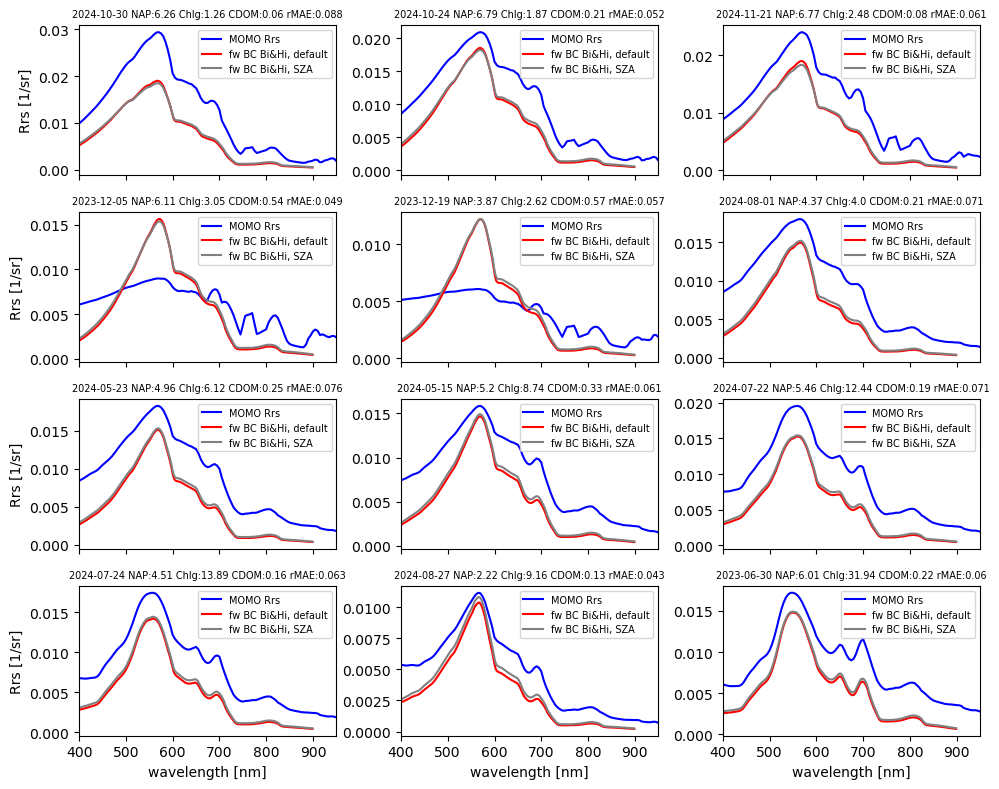

In [176]:
ind = indList ## comment in first view of data
fig, ax=plt.subplots(nrows=Ny, ncols=Nx, figsize=(10,8), sharex=True, sharey=False)

for iy in range(Ny):
    for ix in range(Nx):
        ax[iy, ix].plot(wl_momo, Rrs_momo.loc[ind[iy*Nx+ix],:].values, 'b-', label='MOMO '+ RrsType)
        # ax[iy, ix].plot(wl, Rrs_noglint_sel.iloc[iy*Nx+ix,:].values, '-', color='lightblue', label='MOMO '+ RrsType)
        
        ax[iy, ix].plot(fw_wl, fw_stat.loc[ind[iy*Nx+ix],:].values, 'r-', label='fw BC Bi&Hi, default')
        ax[iy, ix].plot(fw_wl, fw_sza.loc[ind[iy*Nx+ix],:].values, '-', color='grey', label='fw BC Bi&Hi, SZA')
        
        ax[iy, ix].set_title(str(ind[iy*Nx+ix]).split('T')[0] + ' NAP:' + str(np.round(insitu['NAP [mg/l]'].loc[ind[iy*Nx+ix]], 2)) +
                            ' Chlg:' + str(np.round(insitu['Chlg [µg/l]'].loc[ind[iy*Nx+ix]], 2)) +
                            ' CDOM:' + str(np.round(insitu['ag(440) [1/m]'].loc[ind[iy*Nx+ix]], 2))+
                             ' rMAE:' + str(np.round(spectralError['rMAE'].loc[ind[iy*Nx+ix]], 3)), fontsize=7)
        ax[iy, ix].legend(fontsize=7)
        ax[iy, ix].set_xlim((400, 950))
        if iy == Ny-1:
            ax[iy, ix].set_xlabel('wavelength [nm]')
        if ix == 0:
            ax[iy, ix].set_ylabel('Rrs [1/sr]')


fig.tight_layout()
plt.show()

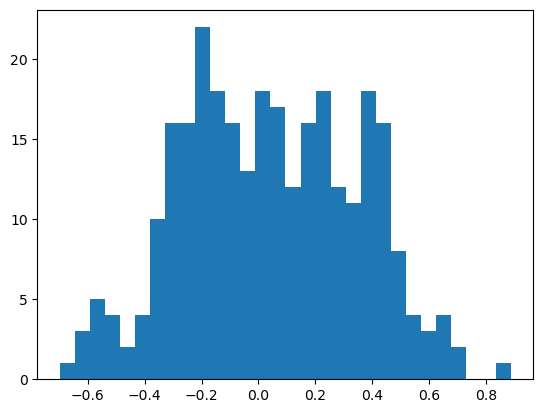

In [174]:
# plt.hist(np.log10(iop_insitu_sel['Chlg [µg/l]'].values), bins=30)
plt.hist(np.log10(iop_insitu_sel['Chlg [µg/l]'].values/iop_insitu_sel['NAP [mg/l]'].values), bins=30)
plt.show()

In [175]:
# Y = np.log10(iop_insitu_sel['Chlg [µg/l]'].values)
Y = np.log10(iop_insitu_sel['Chlg [µg/l]'].values/iop_insitu_sel['NAP [mg/l]'].values)
             
vmin, vmax = (np.min(Y), np.max(Y))
delta = (vmax-vmin)/(Nx*Ny)
selectCHL_target = np.arange(vmin, vmax, delta*0.999)
indList = []
for logchl in selectCHL_target:
    ID = np.abs(Y - logchl) == np.min(np.abs(Y - logchl))
    if np.sum(ID)>1:
        ID2 = np.where(ID)[0]
        ID3 = np.asarray(ID2)[1:]
        ID[ID3] = False
    
    indList.append(iop_insitu_sel.index[ID])

indList = np.asarray(indList).flatten()
indList

array(['2024-10-30T08:06:44.000000000', '2024-10-24T07:03:27.000000000',
       '2024-11-21T09:26:15.000000000', '2023-12-05T15:14:19.000000000',
       '2023-12-19T15:14:02.000000000', '2024-08-01T14:13:41.000000000',
       '2024-05-23T14:10:19.000000000', '2024-05-15T07:03:07.000000000',
       '2024-07-22T07:05:01.000000000', '2024-07-24T07:04:27.000000000',
       '2024-08-27T14:12:30.000000000', '2023-06-30T07:05:42.000000000',
       '2024-09-08T14:13:00.000000000'], dtype='datetime64[ns]')

In [116]:
## select spectra only from the part with systematic errors!
Y = np.log10(iop_insitu_sel['Chlg [µg/l]'].values/iop_insitu_sel['NAP [mg/l]'].values)
IDsyst = spectralError['rMAE'].values < poly_fit4(Y)

Y_ = Y[IDsyst]
iop_insitu_sel2 = iop_insitu_sel.loc[IDsyst,:]
             
vmin, vmax = (np.min(Y_), np.max(Y_))
delta = (vmax-vmin)/(Nx*Ny)
selectCHL_target = np.arange(vmin, vmax, delta*0.999)
indList = []
for logchl in selectCHL_target:
    ID = np.abs(Y_ - logchl) == np.min(np.abs(Y_ - logchl))
    if np.sum(ID)>1:
        ID2 = np.where(ID)[0]
        ID3 = np.asarray(ID2)[1:]
        ID[ID3] = False
    
    indList.append(iop_insitu_sel2.index[ID])

indList = np.asarray(indList).flatten()
indList

array(['2018-12-10T00:00:00.000000000', '2018-11-19T00:00:00.000000000',
       '2016-12-12T00:00:00.000000000', '2020-11-23T00:00:00.000000000',
       '2022-01-24T00:00:00.000000000', '2019-02-04T00:00:00.000000000',
       '2020-02-03T00:00:00.000000000', '2020-01-20T00:00:00.000000000',
       '2022-10-24T00:00:00.000000000', '2015-03-02T00:00:00.000000000',
       '2019-03-04T00:00:00.000000000', '2021-03-01T00:00:00.000000000',
       '2022-09-12T00:00:00.000000000'], dtype='datetime64[ns]')

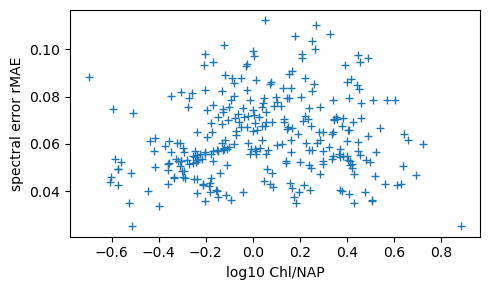

In [177]:
## characterise systematic error ##
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(Y, spectralError['rMAE'].values, '+')
x = np.arange(vmin, vmax, (vmax-vmin) /100.)

## fit systematic error part: select rMAE < 0.125
# ID = spectralError['rMAE'].values < 0.125
# Y_ = spectralError['rMAE'].values[ID]
# X = Y[ID]
# coefficients = np.polyfit(X,Y_, 5)
# poly_fit = np.poly1d(coefficients)
# # ax.plot(x, poly_fit(x), 'g-')
# coeff2 = coefficients.copy()
# coeff2[-1] = 1.2*coeff2[-1]
# poly_fit2 = np.poly1d(coeff2)
# # ax.plot(x, poly_fit2(x), 'r-')

# ID = spectralError['rMAE'].values < poly_fit2(Y)
# Y_ = spectralError['rMAE'].values[ID]
# X = Y[ID]
# coeff3 = np.polyfit(X,Y_, 5)
# poly_fit3 = np.poly1d(coeff3)
# ax.plot(x, poly_fit3(x), 'b-')
# coeff4 = coeff3.copy()
# coeff4[-1] = 1.2*coeff4[-1]
# poly_fit4 = np.poly1d(coeff4)
# ax.plot(x, poly_fit4(x), 'r-') ## Use these only for a study of the systematic error!

# print('fit')
# print(coeff3)
# print('fit + offset')
# print(coeff4)

ax.set_ylabel('spectral error rMAE')
ax.set_xlabel('log10 Chl/NAP')
fig.tight_layout()
plt.show()


In [74]:
## Errors of Reconstructed spectra
def setup_spectral_error_df(Xtrain, X_projected):
    SpectralErrorDF = pd.DataFrame()

    rMAE = np.zeros(Xtrain.shape[0])
    sam = np.zeros(Xtrain.shape[0])

    rMAE = np.sqrt(np.sum((Xtrain - X_projected) ** 2, axis=1)) / np.sum(Xtrain, axis=1)
    sqrtsum2_orig = np.sqrt(np.sum(Xtrain ** 2, axis=1))
    sqrtsum2_inv = np.sqrt(np.sum(X_projected ** 2, axis=1))
    sam = np.sum((Xtrain * X_projected), axis=1) / (sqrtsum2_orig * sqrtsum2_inv)
    sam = np.arccos(sam)

    sam *= 180. / np.pi
    SpectralErrorDF['rMAE'] = rMAE
    SpectralErrorDF['SAM'] = sam
    SpectralErrorDF['absErr'] = np.sum(np.abs(X_projected - Xtrain), axis=1)

    return SpectralErrorDF

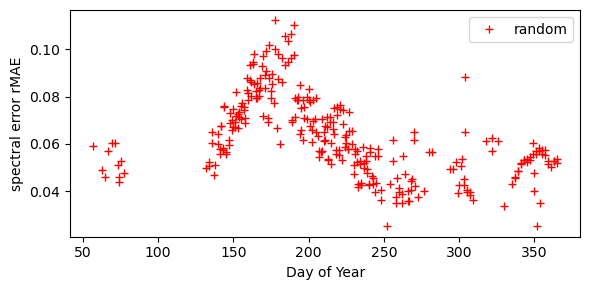

In [178]:
## plot timeseries: all errors and systematic ones
fig, ax = plt.subplots(figsize=(6,3))
doy = np.asarray([a.day_of_year for a in spectralError.index])
ax.plot(doy, spectralError['rMAE'], 'r+', label='random')
# IDsyst = spectralError['rMAE'].values < poly_fit4(Y)
# ax.plot(doy[IDsyst], spectralError['rMAE'].loc[IDsyst], 'b+', label='systematic')
ax.legend()
ax.set_ylabel('spectral error rMAE')
ax.set_xlabel('Day of Year')
fig.tight_layout()
plt.show()

# CHIME SNR - Version 1
Signal-to-noise is defined on radiances at top of atmosphere.  
<!-- Our simulation data are reflectances at bottom of atmosphere.   -->
MOMO simulations include TOA radiance, so it is possible to have an estimate of the error for the different wavelengths at TOA radiance.  
We can use the MOMO simulations to calculate the impact on the reflectance under perfect conditions!  

see: Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\AQUATIME_Overview_Simulation_Inversion_20260331.pptx  


In [179]:
pathSNR = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\CHIME_SNR\\"

SNR = pd.read_csv(pathSNR + "SNR_g_No_coeff.csv", header=0)
Ref = pd.read_csv(pathSNR + "SSRD_AD11 CHIME radiance levels v4.csv", header=0)


In [181]:
Ref

,wavelength (nm),Lmin (W/sr/m2/micron),Lref_L ((W/sr/m2/micron)),Lmax (W/sr/m2/micron)
0,400,57.200,139.90000,576.900
1,401,55.610,137.30000,563.500
2,402,55.560,140.80000,566.600
3,403,53.920,134.90000,553.500
4,404,53.750,121.80000,555.500
...,...,...,...,...
2096,2496,0.004,0.01901,0.322
2097,2497,0.004,0.03225,0.322
2098,2498,0.004,0.06649,0.322
2099,2499,0.004,0.03668,0.390


In [211]:
SNR

,Wavelength [nm],g,N0
0,404.2,298.624928,1.477043
1,412.6,340.045687,1.139124
2,421.0,359.345786,1.020047
3,429.4,362.448827,1.007215
4,437.8,397.359474,0.868355
...,...,...,...
245,2462.2,69.403332,8.525178
246,2470.6,48.706035,17.310059
247,2479.0,32.256519,39.466544
248,2487.4,13.538347,224.043744


In [358]:
versionNumber = 'v1.0' # helsinki: v1.0, mueggelsee-berlin: default: v0.2 - updated MOMO model
regionName = 'finnmaid-helsinki'

if regionName == "helsinki_silja_serenade": ## Rrs is wrong here!
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\"
    versionNumber = 'v0.4.1'
if regionName == 'finnmaid-helsinki':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\"
    versionNumber = 'v0.3.1'
if regionName == 'muggelsee':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\"
    versionNumber = 'v0.3.0' #'v2.0'

if regionName == 'vortsjarv':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\\vortsjarv\\"
    versionNumber = 'v0.3'

fnames = os.listdir(path)
fnameLsur = [fn for fn in fnames if 'rad-up-sur' in fn and versionNumber in fn][0]
fnameLtoa = [fn for fn in fnames if 'rad-up-toa' in fn and versionNumber in fn][0]
fnameRrs = [fn for fn in fnames if 'Rrs_' in fn and versionNumber in fn][0] # WRONG??
fnameEd = [fn for fn in fnames if 'irr-dn-sur' in fn and versionNumber in fn][0]
fnameEdir = [fn for fn in fnames if 'irr-dn-vec-sur' in fn and versionNumber in fn][0]

print(fnameLsur)
print(fnameLtoa)
print(fnameRrs)
print(fnameEd)
print(fnameEdir)

def read_MOMO_data(path, fname):
    L = pd.read_csv(path + fname, header=0)
    L['date'] = pd.to_datetime(L['date'])
    L = L.set_index('date')
    return L

Rrs = read_MOMO_data(path, fnameRrs)
varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum', 'QWIP']
for v in varList:
    if v in Rrs.columns.values:
        Rrs = Rrs.drop(columns=[v])
Ltoa = read_MOMO_data(path, fnameLtoa)
Lsur = read_MOMO_data(path, fnameLsur)
Ed = read_MOMO_data(path, fnameEd)
Edir = read_MOMO_data(path, fnameEdir)

Rrs_test = Lsur / (Ed + Edir)

wl = np.asarray([float(a) for a in Lsur.columns.values])
wlstr = [str(a) for a in wl]

## total transmission in MOMO
t_tot = Lsur/Ltoa

## build Ltoa / Lref 
# select Lref at the MOMO wavelengths
## MOMO-factor ##
MOMOfac = 1000.
ID = [np.argwhere(a == Ref.iloc[:,0].values).flatten()[0] for a in wl]
L_Lref = Ltoa.copy()*MOMOfac
for i in range(L_Lref.shape[0]):
    L_Lref.iloc[i,:] = L_Lref.iloc[i,:]/ Ref.iloc[ID, 2].values

HEATWISE_D2.1.0_RD-finnmaid_daily-chime-simulated-5nm-rad-up-sur_v0.3.1.csv
HEATWISE_D2.1.0_RD-finnmaid_daily-chime-simulated-5nm-rad-up-toa_v0.3.1.csv
HEATWISE_D2.1.0_RD-finnmaid_daily-chime-simulated-5nm-Rrs_v0.3.1.csv
HEATWISE_D2.1.0_RD-finnmaid_daily-chime-simulated-5nm-irr-dn-sur_v0.3.1.csv
HEATWISE_D2.1.0_RD-finnmaid_daily-chime-simulated-5nm-irr-dn-vec-sur_v0.3.1.csv


MOMO spectra Ltoa can't be in W/ (sr m^2 micron)! Values would be substantially too low!  
From a publication: *Li, C.; Liu, J.; He, Q.; Xu, M.; Li, M. Assessing Radiance Contributions Above Near-Space over the Ocean Using Radiative Transfer Simulation. Remote Sens. 2026, 18, 337. https://doi.org/10.3390/rs18020337*  
MOMO data is mostly similar to mW/(cm^2 nm sr) which gives a factor of 10^4. (??)  
  
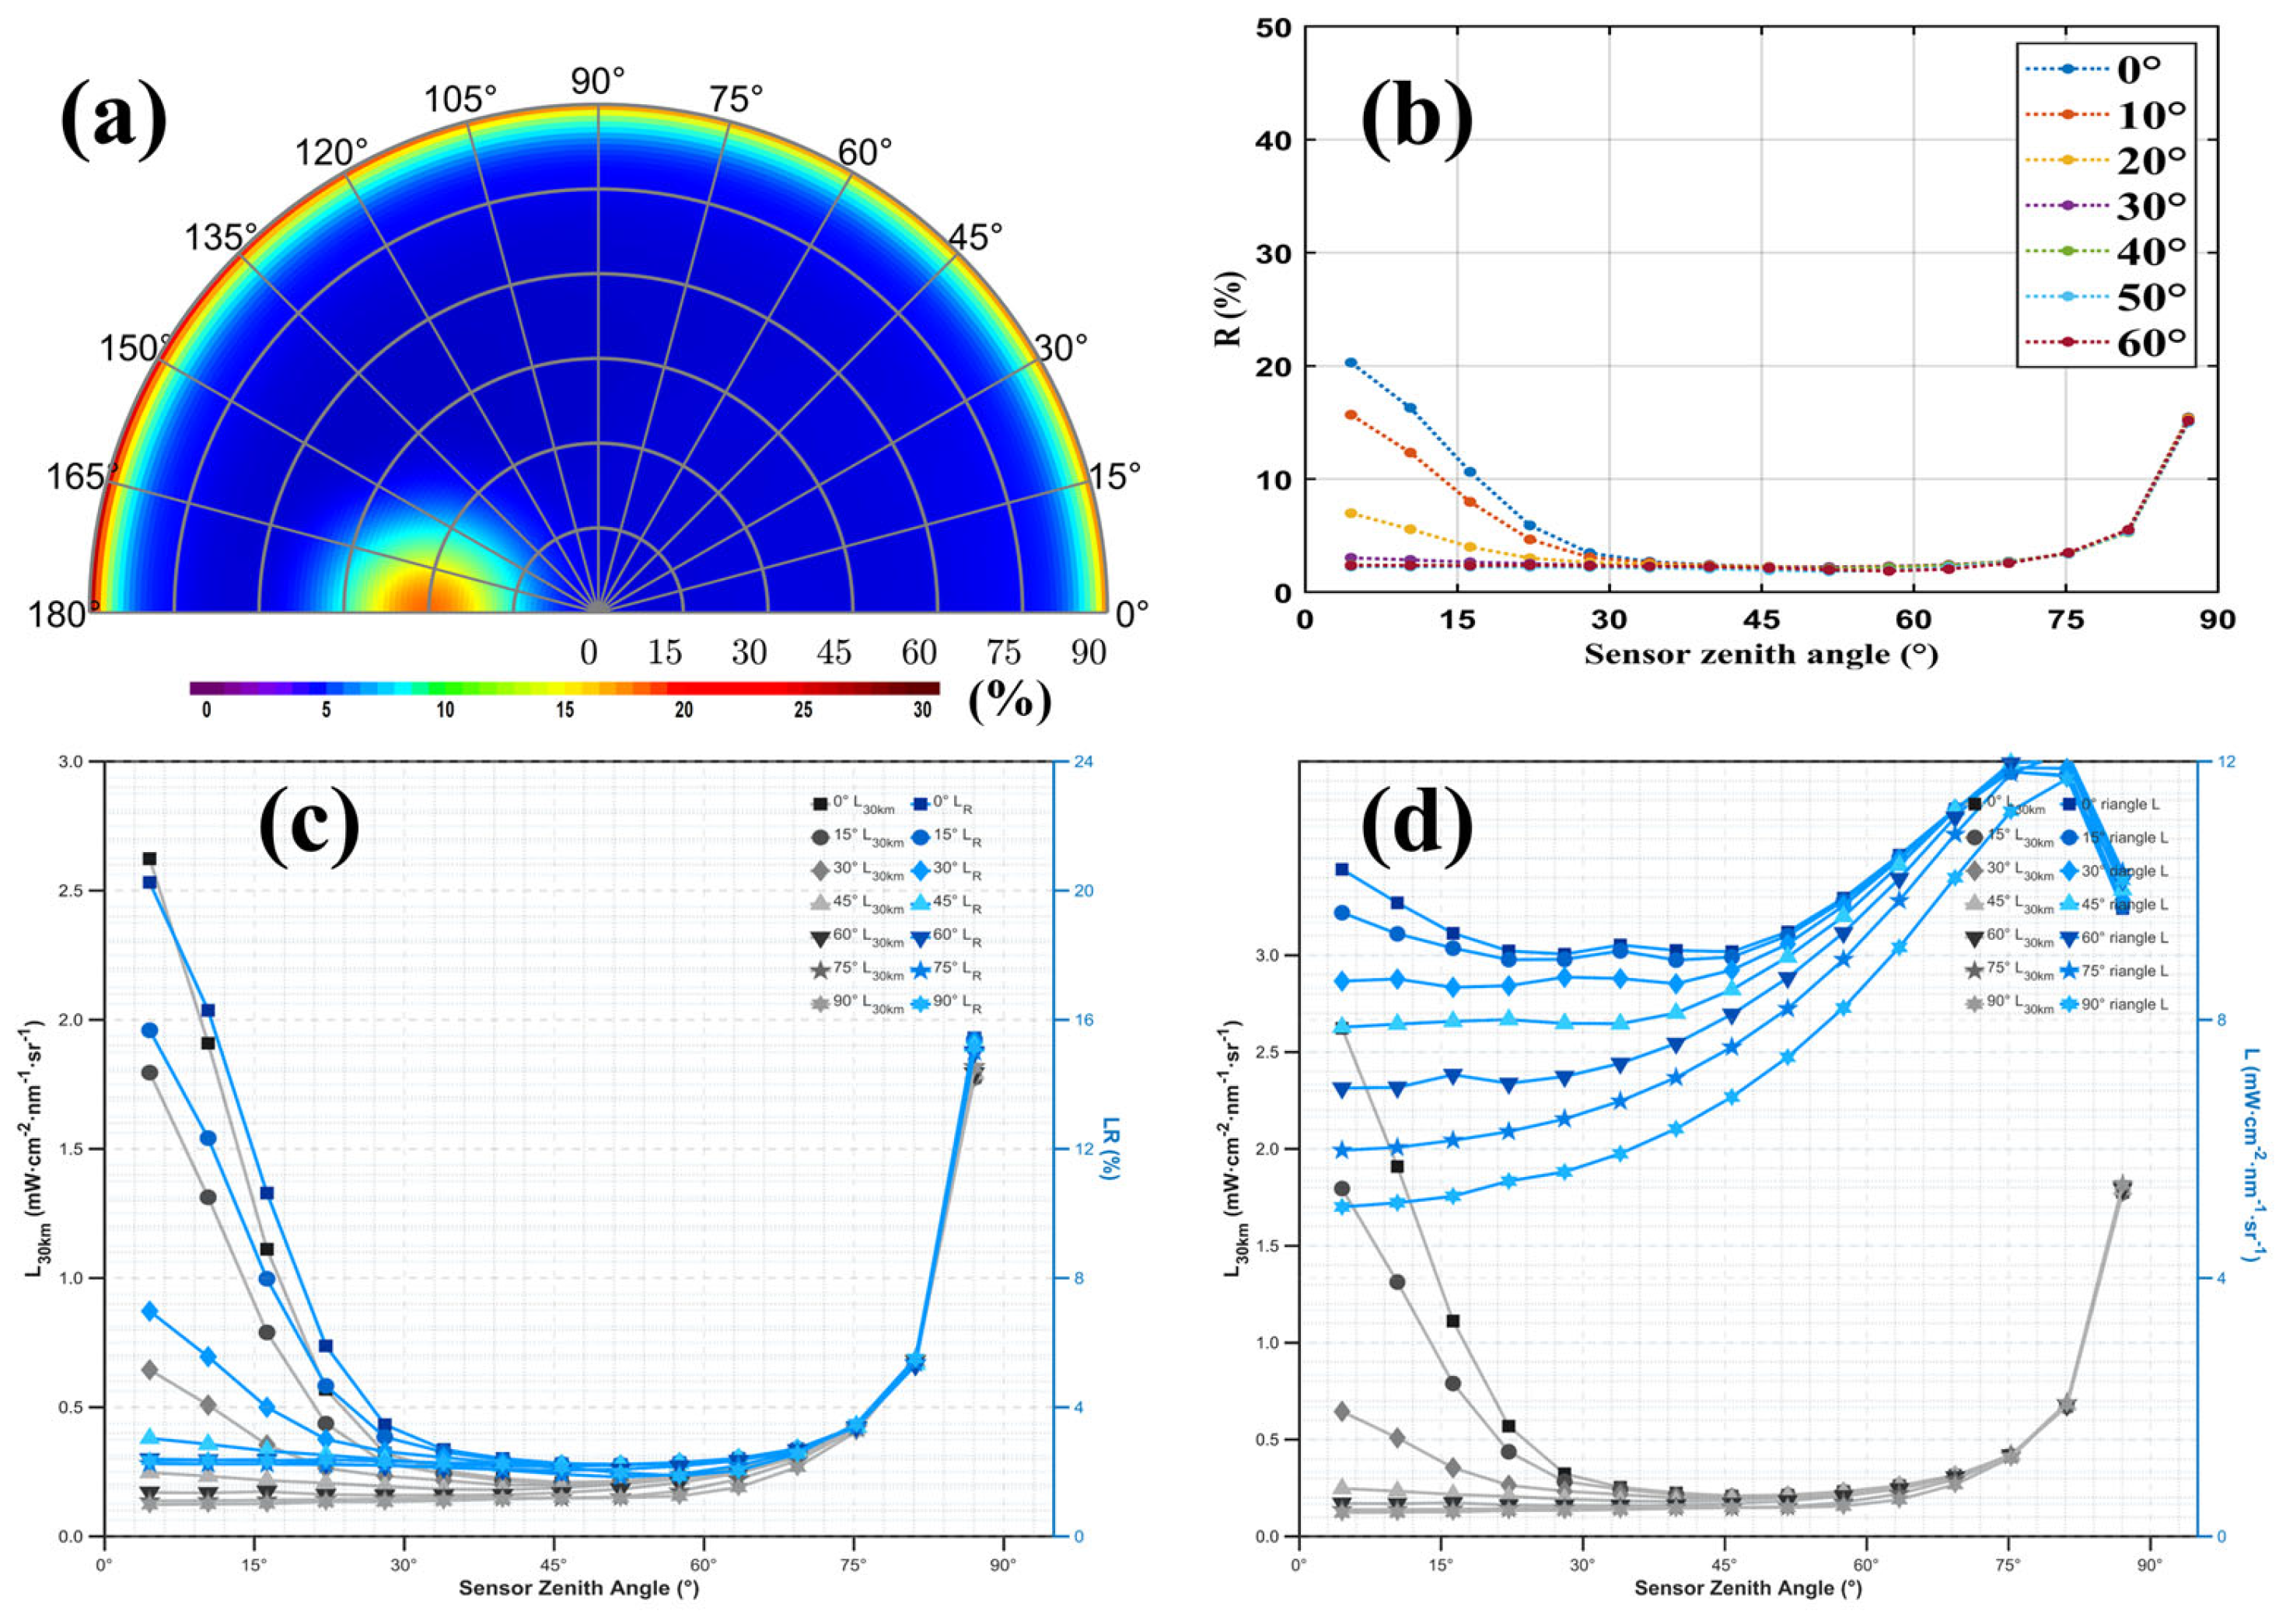

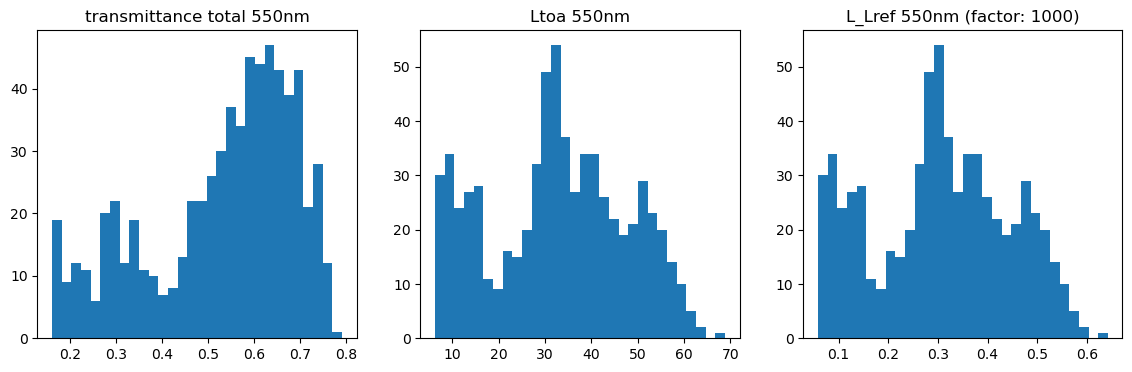

In [359]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,4))
ax[0].hist(t_tot['550'].values, 30)
ax[0].set_title('transmittance total 550nm')
ax[1].hist(Ltoa['550'].values*MOMOfac, 30) # guess: in W/sr/m^2/nm -> 10^3 W/sr/m^2/micron // could also be mW/ (cm^2 nm sr) = 10^4 W/(m^2 micron sr)
ax[1].set_title('Ltoa 550nm')

ax[2].hist(L_Lref['550'].values, 30)
ax[2].set_title('L_Lref 550nm (factor: '+str(int(MOMOfac))+')')

plt.show()

In [360]:
## calculate all to CHIME center wavelengths of bands

## transmittance at CHIME
ID = SNR.iloc[:,0].values < 1000
wl_ = SNR.iloc[:,0].values[ID]

t_tot_CHIME = np.zeros((t_tot.shape[0], len(wl_)))
L_Lref_CHIME = np.zeros((L_Lref.shape[0], len(wl_)))
for i in range(t_tot_CHIME.shape[0]):
    wl_1, t_tot_ = splineFit(wl, t_tot.iloc[i,:].values, x_=wl_)
    t_tot_CHIME[i,:] = t_tot_
    L_Lref_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=L_Lref.iloc[i,:].values)

def SNR_function(SNR_df, L_Lref, valid): # at wavelengths of CHIME in SNR_df!
    snr = L_Lref.copy()
    for i in range(snr.shape[0]):
        snr[i,:] = L_Lref[i,:] * SNR_df['g'].values[valid]/ np.sqrt(L_Lref[i,:] + SNR_df['N0'].values[valid])
    return snr

snrArr = SNR_function(SNR, L_Lref_CHIME, ID)

## noise at water level with wavelenghts of CHIME
Ltoa_CHIME = np.zeros((Ltoa.shape[0], len(wl_)))
Lsur_CHIME = np.zeros((Lsur.shape[0], len(wl_)))
Ed_CHIME = np.zeros((Ed.shape[0], len(wl_)))
Edir_CHIME = np.zeros((Edir.shape[0], len(wl_)))
for i in range(Ltoa_CHIME.shape[0]):
    Ltoa_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Ltoa.iloc[i,:].values)
    Lsur_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Lsur.iloc[i,:].values)
    Ed_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Ed.iloc[i,:].values)
    Edir_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Edir.iloc[i,:].values)

noise_water = t_tot_CHIME * (Ltoa_CHIME) * np.random.normal(size=t_tot_CHIME.shape) / snrArr 
Rrs_noise = (Lsur_CHIME + noise_water)/(Ed_CHIME + Edir_CHIME)

In [352]:
if regionName == 'vortsjarv':
    # read insitu spectra
    ## CAUTION: these are water leaving reflectances! Divide by pi to convert to Rrs
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\Case_Study_3\Vortsjarv\Hyperspectral data\\"
    insituRrs = pd.read_csv(path+ "Hypstar_radiometric_23-24.csv", header=0)
    datetimeStr = [str(dt) + ' 12:00:00' for dt in insituRrs['Date'].values]
    insituRrs['date'] = pd.to_datetime(datetimeStr, format= '%Y%m%d %H:%M:%S')
    insituRrs = insituRrs.set_index('date')
    wl_ins = np.asarray([float(a) for a in insituRrs.columns.values[1:]])
    insituRrs = insituRrs.drop(columns=['Date'])
    insituRrs.loc[:,:] = insituRrs.loc[:,:].values / np.pi
    insituRrs

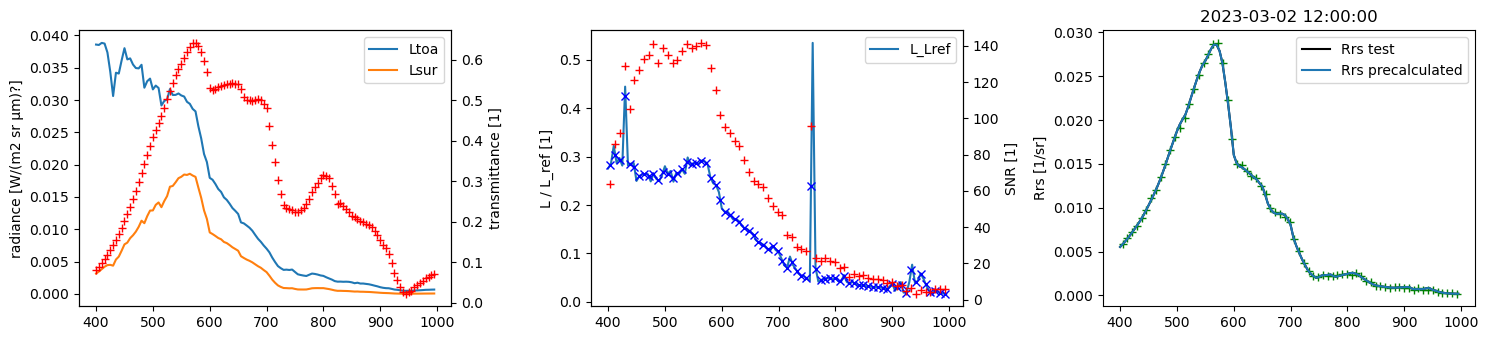

In [361]:
ispec = 7

fig, ax = plt.subplots(ncols=3, figsize=(15,3.5))
ax[0].plot(wl, Ltoa.iloc[ispec,:], '-', label='Ltoa')
ax[0].plot(wl, Lsur.iloc[ispec,:], '-', label='Lsur')
# ax[0].plot(wl, Rrs.iloc[ispec,:], '-', label='Rrs')
ax[0].set_ylabel('radiance [W/(m2 sr µm)?]')
ax[0].legend()
ax1 = ax[0].twinx()
ax1.plot(wl, t_tot.iloc[ispec,:], 'r+')
ax1.set_ylabel('transmittance [1]')


ax[1].plot(wl, L_Lref.iloc[ispec,:], '-', label='L_Lref')
ax[1].plot(wl_, L_Lref_CHIME[ispec], 'x', color='blue')
ax[1].set_ylabel('L / L_ref [1]')
ax[1].legend()


ax2 = ax[1].twinx()
ax2.plot(wl_, snrArr[ispec,:], 'r+')
ax2.set_ylabel('SNR [1]')

# ax[2].plot(wl, Lsur.iloc[0,:].values, '-', label='Lsur')
# ax[2].plot(wl_, Lsur_CHIME[0,:] + noise_water[0,:], '+')
# ax[2].set_ylabel('radiance [W/(m2 sr µm)?]')

# ax3 = ax[2].twinx()
ax[2].plot(wl, Rrs_test.iloc[ispec,:], 'k-', label='Rrs test')
ax[2].plot(wl_, Rrs_noise[ispec,:], 'g+')
ax[2].plot(wl, Rrs.iloc[ispec,:], '-', label='Rrs precalculated')

if regionName == 'vortsjarv':
    if Rrs.index[ispec] in insituRrs.index:
        ax[2].plot(wl_ins, insituRrs.loc[Rrs.index[ispec],:], '-', label='insitu')

ax[2].set_title(str(Rrs.index[ispec]))
    
ax[2].set_ylabel('Rrs [1/sr]')
ax[2].legend()
fig.tight_layout()
plt.show()


In [216]:
from scipy.interpolate import make_smoothing_spline
def splineFit(X, Y, x_=None, delta=1, lam=0, ax=None, color=None, marker='-', logY=False):
    if logY:
        ID = Y == 0
        Y[ID] = np.max(Y) * 0.001
        spl = make_smoothing_spline(X, np.log10(Y), lam=lam)
    else:
        spl = make_smoothing_spline(X, Y, lam=lam)

    if x_ is None:
        x_ = np.arange(np.min(X), np.max(X)+delta, delta)
    y_ = spl(x_)
    if logY:
        y_ = 10**y_
    
    if not ax is None:
        ax.plot(x_, y_, marker, color=color)

    return x_, y_

# CHIME SNR - Version 2
Signal-to-noise is defined on radiances at top of atmosphere.  
<!-- Our simulation data are reflectances at bottom of atmosphere.   -->
MOMO simulations include TOA radiance, so it is possible to have an estimate of the error for the different wavelengths at TOA radiance.  
We can use the MOMO simulations to calculate the impact on the reflectance under perfect conditions!  

see: Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\AQUATIME_Overview_Simulation_Inversion_20260331.pptx  


In [362]:
pathSNR = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\CHIME_SNR\\"

SNR = pd.read_csv(pathSNR + "SNR_g_No_coeff.csv", header=0)
Ref = pd.read_csv(pathSNR + "SSRD_AD11 CHIME radiance levels v4.csv", header=0)

In [372]:
versionNumber = 'v1.0' # helsinki: v1.0, mueggelsee-berlin: default: v0.2 - updated MOMO model
regionName = 'muggelsee' #'finnmaid-helsinki'

if regionName == "helsinki_silja_serenade": ## Rrs is wrong here!
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_siljaserenade\\"
    versionNumber = 'v0.4.1'
if regionName == 'finnmaid-helsinki':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\helsinki_finnmaid\\"
    versionNumber = 'v0.3.1'
if regionName == 'muggelsee':
    path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\"
    versionNumber = 'v2.0' # something is wrong with version v0.3.0!

if regionName == 'vortsjarv':
    path = "Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\Simulated Spectra\\vortsjarv\\"
    versionNumber = 'v0.3'

fnames = os.listdir(path)
fnameLsur = [fn for fn in fnames if 'rad-up-sur' in fn and versionNumber in fn][0]
fnameLtoa = [fn for fn in fnames if 'rad-up-toa' in fn and versionNumber in fn][0]
fnameRrs = [fn for fn in fnames if 'Rrs_' in fn and versionNumber in fn][0] # WRONG??
fnameEd = [fn for fn in fnames if 'irr-dn-sur' in fn and versionNumber in fn][0]
fnameEdir = [fn for fn in fnames if 'irr-dn-vec-sur' in fn and versionNumber in fn][0]

print(fnameLsur)
print(fnameLtoa)
print(fnameRrs)
print(fnameEd)
print(fnameEdir)

def read_MOMO_data(path, fname):
    L = pd.read_csv(path + fname, header=0)
    L['date'] = pd.to_datetime(L['date'])
    L = L.set_index('date')
    return L

Rrs = read_MOMO_data(path, fnameRrs)
varList = ['AVW', 'Area', 'NDI', 'OWT', 'membSum', 'QWIP']
for v in varList:
    if v in Rrs.columns.values:
        Rrs = Rrs.drop(columns=[v])
Ltoa = read_MOMO_data(path, fnameLtoa)
Lsur = read_MOMO_data(path, fnameLsur)
Ed = read_MOMO_data(path, fnameEd)
Edir = read_MOMO_data(path, fnameEdir)

Rrs_test = Lsur / (Ed + Edir)

wl = np.asarray([float(a) for a in Lsur.columns.values])
wlstr = [str(a) for a in wl]

## transmission in MOMO
t_tot = 0.1 * Ltoa/Lsur

## build Ltoa / Lref 
# select Lref at the MOMO wavelengths
## MOMO-factor ##
MOMOfac = 1000.
ID = [np.argwhere(a == Ref.iloc[:,0].values).flatten()[0] for a in wl]
L_Lref = Ltoa.copy()*MOMOfac
for i in range(L_Lref.shape[0]):
    L_Lref.iloc[i,:] = L_Lref.iloc[i,:]/ Ref.iloc[ID, 2].values

HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-rad-up-sur_v2.0.csv
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-rad-up-toa_v2.0.csv
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-Rrs_v2.0.csv
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-irr-dn-sur_v2.0.csv
HEATWISE_D2.1.0_RD-muggelsee-berlin-chime-simulated-5nm-irr-dn-vec-sur_v2.0.csv


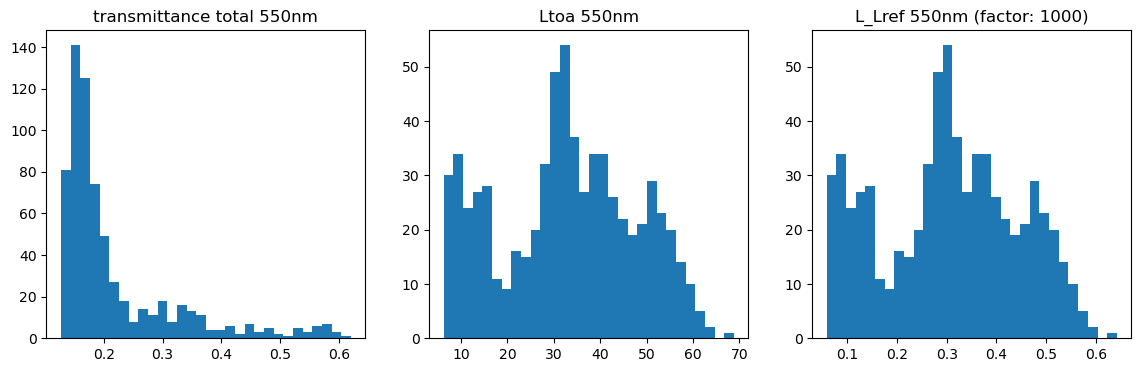

In [364]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,4))
ax[0].hist(t_tot['550'].values, 30)
ax[0].set_title('transmittance total 550nm')
ax[1].hist(Ltoa['550'].values*MOMOfac, 30) # guess: in W/sr/m^2/nm -> 10^3 W/sr/m^2/micron // could also be mW/ (cm^2 nm sr) = 10^4 W/(m^2 micron sr)
ax[1].set_title('Ltoa 550nm')

ax[2].hist(L_Lref['550'].values, 30)
ax[2].set_title('L_Lref 550nm (factor: '+str(int(MOMOfac))+')')

plt.show()

In [367]:
## calculate all to CHIME center wavelengths of bands

## transmittance at CHIME
ID = SNR.iloc[:,0].values < 1000
wl_ = SNR.iloc[:,0].values[ID]

t_tot_CHIME = np.zeros((t_tot.shape[0], len(wl_)))
L_Lref_CHIME = np.zeros((L_Lref.shape[0], len(wl_)))
for i in range(t_tot_CHIME.shape[0]):
    wl_1, t_tot_ = splineFit(wl, t_tot.iloc[i,:].values, x_=wl_)
    t_tot_CHIME[i,:] = t_tot_
    L_Lref_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=L_Lref.iloc[i,:].values)

def SNR_function(SNR_df, L_Lref, valid): # at wavelengths of CHIME in SNR_df!
    snr = L_Lref.copy()
    for i in range(snr.shape[0]):
        snr[i,:] = L_Lref[i,:] * SNR_df['g'].values[valid]/ np.sqrt(L_Lref[i,:] + SNR_df['N0'].values[valid])
    return snr

snrArr = SNR_function(SNR, L_Lref_CHIME, ID)

## noise at water level with wavelenghts of CHIME
Ltoa_CHIME = np.zeros((Ltoa.shape[0], len(wl_)))
Lsur_CHIME = np.zeros((Lsur.shape[0], len(wl_)))
Ed_CHIME = np.zeros((Ed.shape[0], len(wl_)))
Edir_CHIME = np.zeros((Edir.shape[0], len(wl_)))
for i in range(Ltoa_CHIME.shape[0]):
    Ltoa_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Ltoa.iloc[i,:].values)
    Lsur_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Lsur.iloc[i,:].values)
    Ed_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Ed.iloc[i,:].values)
    Edir_CHIME[i,:] = np.interp(x = wl_, xp=np.asarray(wl), fp=Edir.iloc[i,:].values)

noise_water = 10.*Lsur_CHIME/snrArr * np.random.normal(size=t_tot_CHIME.shape) # version 2
# noise_water = t_tot_CHIME * (Ltoa_CHIME) * np.random.normal(size=t_tot_CHIME.shape) / snrArr # version 1
Rrs_noise = (Lsur_CHIME + noise_water)/(Ed_CHIME + Edir_CHIME)

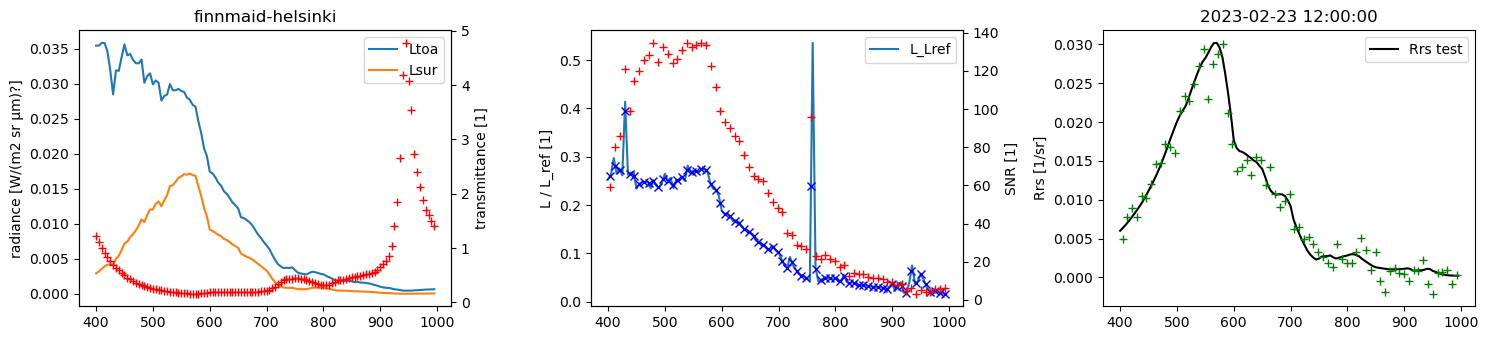

In [371]:
ispec = 0

fig, ax = plt.subplots(ncols=3, figsize=(15,3.5))
ax[0].plot(wl, Ltoa.iloc[ispec,:], '-', label='Ltoa')
ax[0].plot(wl, Lsur.iloc[ispec,:], '-', label='Lsur')
# ax[0].plot(wl, Rrs.iloc[ispec,:], '-', label='Rrs')
ax[0].set_title(regionName)
ax[0].set_ylabel('radiance [W/(m2 sr µm)?]')
ax[0].legend()
ax1 = ax[0].twinx()
ax1.plot(wl, t_tot.iloc[ispec,:], 'r+')
ax1.set_ylabel('transmittance [1]')


ax[1].plot(wl, L_Lref.iloc[ispec,:], '-', label='L_Lref')
ax[1].plot(wl_, L_Lref_CHIME[ispec], 'x', color='blue')
ax[1].set_ylabel('L / L_ref [1]')
ax[1].legend()


ax2 = ax[1].twinx()
ax2.plot(wl_, snrArr[ispec,:], 'r+')
ax2.set_ylabel('SNR [1]')

# ax[2].plot(wl, Lsur.iloc[0,:].values, '-', label='Lsur')
# ax[2].plot(wl_, Lsur_CHIME[0,:] + noise_water[0,:], '+')
# ax[2].set_ylabel('radiance [W/(m2 sr µm)?]')

# ax3 = ax[2].twinx()
ax[2].plot(wl, Rrs_test.iloc[ispec,:], 'k-', label='Rrs test')
ax[2].plot(wl_, Rrs_noise[ispec,:], 'g+')
# ax[2].plot(wl, Rrs.iloc[ispec,:], '-', label='Rrs precalculated')

if regionName == 'vortsjarv':
    if Rrs.index[ispec] in insituRrs.index:
        ax[2].plot(wl_ins, insituRrs.loc[Rrs.index[ispec],:], '-', label='insitu')

ax[2].set_title(str(Rrs.index[ispec]))
    
ax[2].set_ylabel('Rrs [1/sr]')
ax[2].legend()
fig.tight_layout()
plt.show()


# Check simulations - Mueggelsee 
TOA Radiance simulations and OLCI L1b data

In [390]:
d.columns.values

array(['CALVALUS_ID', 'Name', 'Lat', 'Lon', 'source_name', 'pixel_time',
       'pixel_x', 'pixel_y', 'pixel_lat', 'pixel_lon', 'Oa01_radiance',
       'Oa02_radiance', 'Oa03_radiance', 'Oa04_radiance', 'Oa05_radiance',
       'Oa06_radiance', 'Oa07_radiance', 'Oa08_radiance', 'Oa09_radiance',
       'Oa10_radiance', 'Oa11_radiance', 'Oa12_radiance', 'Oa13_radiance',
       'Oa14_radiance', 'Oa15_radiance', 'Oa16_radiance', 'Oa17_radiance',
       'Oa18_radiance', 'Oa19_radiance', 'Oa20_radiance', 'Oa21_radiance',
       'altitude', 'latitude', 'longitude', 'detector_index',
       'FWHM_band_1', 'FWHM_band_2', 'FWHM_band_3', 'FWHM_band_4',
       'FWHM_band_5', 'FWHM_band_6', 'FWHM_band_7', 'FWHM_band_8',
       'FWHM_band_9', 'FWHM_band_10', 'FWHM_band_11', 'FWHM_band_12',
       'FWHM_band_13', 'FWHM_band_14', 'FWHM_band_15', 'FWHM_band_16',
       'FWHM_band_17', 'FWHM_band_18', 'FWHM_band_19', 'FWHM_band_20',
       'FWHM_band_21', 'frame_offset', 'lambda0_band_1', 'lambda0_band_2

In [410]:
### Example Mueggelsee OLCI L1b ##
# Calvalus extractions: check within OZA<=6°, no clouds
# not sure, which location is best. Probably, try to take all spectra of one day and use them as one.

olci_path = "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Muggelsee - Berlin\mueggelsee_OLCI_L1b_b\\"
fnames = os.listdir(olci_path)
fnames = [fn for fn in fnames if fn.startswith('records-all.starting')]

d = None
for fn in fnames:
    if d is None:
        d = pd.read_csv(olci_path + fn, header=0, sep='\t')
    else:
        d_ = pd.read_csv(olci_path + fn, header=0, sep='\t')
        d = pd.concat([d, d_])

## OZA close to nadir
print(d.shape)
ID = d.OZA.values <=6.
d = d.loc[ID,:]
print(d.shape)
# flags = [a for a in d.columns.values if 'idepix' in a or 'flags' in a]
# validPixel = np.sum(d[['pixel_classif_flags.IDEPIX_CLOUD', 'pixel_classif_flags.IDEPIX_SNOW_ICE', 'quality_flags.invalid']], axis=1)==0
validPixel = np.sum(d[[ 'quality_flags.bright', 'quality_flags.invalid']], axis=1)==0
d = d.loc[validPixel,:]
print(d.shape)

radianceOLCIList = [a for a in d.columns.values if a.startswith('Oa') and a.endswith('radiance')]
solarfluxOLCIList = [a for a in d.columns.values if a.startswith('solar_flux') ]
SZA = d['SZA'].values

def radianceToReflectance(rad, sza, e0): 
    return rad * np.pi / (e0 * np.cos(sza * np.pi/180.))

radiance = d[radianceOLCIList].values
solarflux = d[solarfluxOLCIList].values
reflectance = np.zeros(radiance.shape)
for i in range(len(radianceOLCIList)):
    d[radianceOLCIList[i].split('_')[0]+'_reflectance'] = radianceToReflectance(radiance[:,i], SZA, solarflux[:,i])

reflectanceOLCIList = [a for a in d.columns.values if a.startswith('Oa') and a.endswith('reflectance')]

#[561.1 871.7]
d['NDWI'] = (d['Oa06_reflectance'] - d['Oa18_reflectance']) /(d['Oa06_reflectance'] + d['Oa18_reflectance'])


dateStr = [t.split(' ')[0] for t in d.pixel_time]
d['date'] = pd.to_datetime(dateStr)
d = d.set_index('date')
commonDate = np.intersect1d(d.index, Rrs.index)
commonDate

(20023, 170)
(2402, 170)
(1144, 170)


array(['2018-04-09T00:00:00.000000000', '2018-05-14T00:00:00.000000000',
       '2018-07-30T00:00:00.000000000', '2018-10-15T00:00:00.000000000',
       '2019-02-04T00:00:00.000000000', '2019-02-18T00:00:00.000000000',
       '2019-08-12T00:00:00.000000000', '2019-08-26T00:00:00.000000000',
       '2019-10-28T00:00:00.000000000', '2019-11-11T00:00:00.000000000',
       '2020-06-08T00:00:00.000000000', '2020-08-24T00:00:00.000000000',
       '2020-09-07T00:00:00.000000000', '2020-11-23T00:00:00.000000000',
       '2021-05-17T00:00:00.000000000', '2021-05-31T00:00:00.000000000',
       '2021-06-21T00:00:00.000000000', '2021-09-06T00:00:00.000000000',
       '2021-11-22T00:00:00.000000000', '2022-03-14T00:00:00.000000000',
       '2022-03-28T00:00:00.000000000', '2022-05-30T00:00:00.000000000',
       '2022-06-13T00:00:00.000000000', '2022-07-04T00:00:00.000000000',
       '2023-03-27T00:00:00.000000000', '2023-05-30T00:00:00.000000000',
       '2023-06-12T00:00:00.000000000', '2023-06-26

In [411]:
len(commonDate)

30

-0.12853859073021714


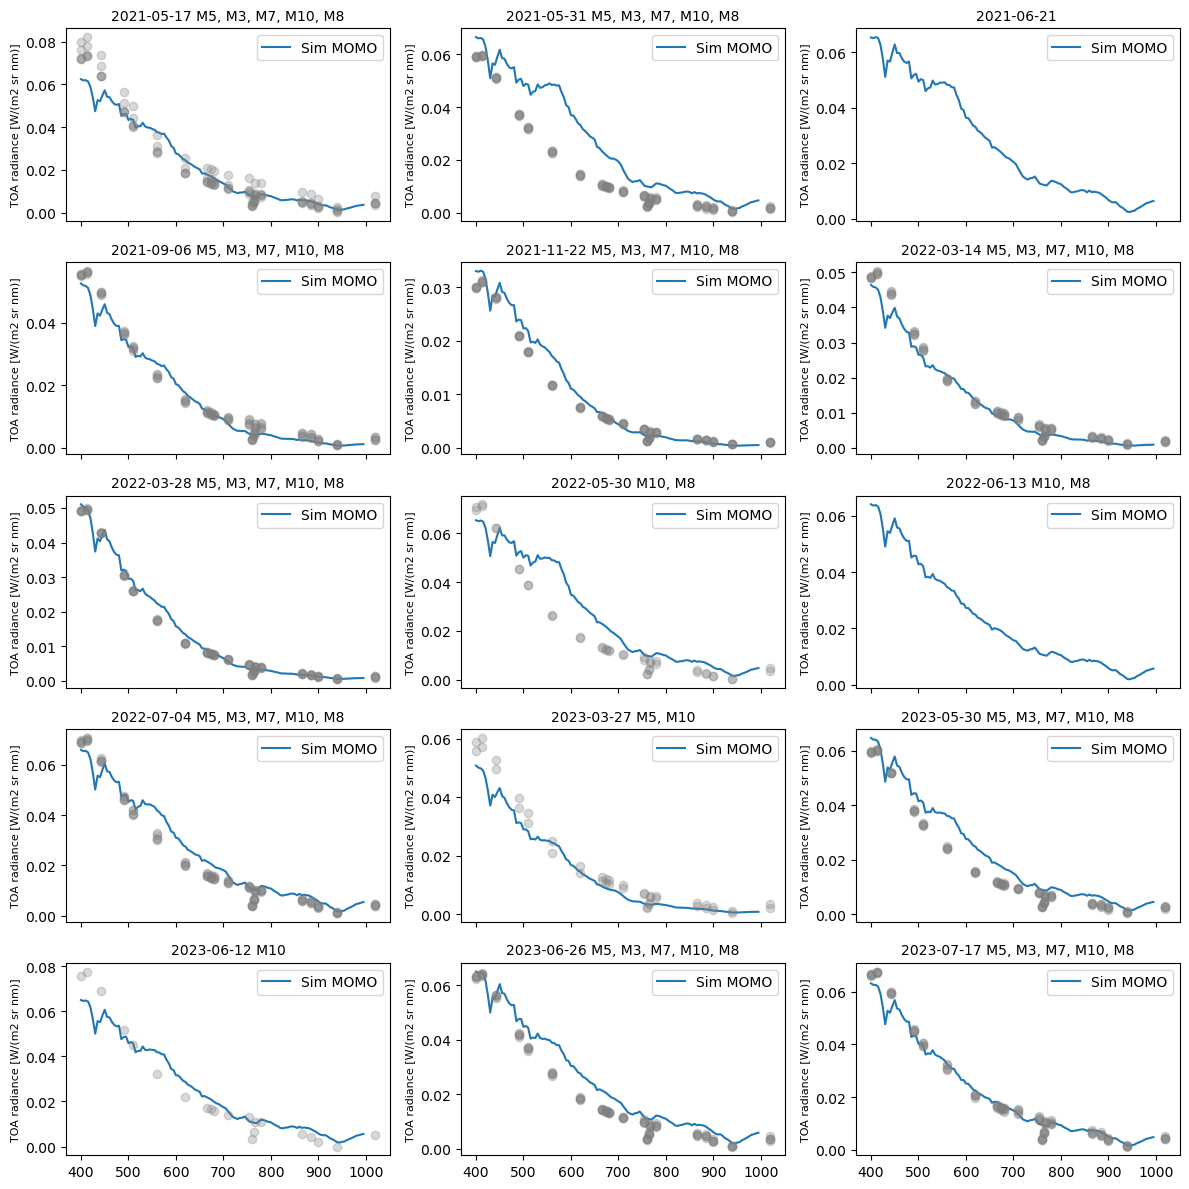

In [418]:
wavelengths_olci = np.asarray((400.0, 412.5, 442.5, 490.0, 510.0, 560.0, 620.0, 665.0, 673.75, 681.25, 708.75, 753.75, 761.25,
                          764.375, 767.5, 778.75, 865.0, 885.0, 900.0, 940.0, 1020.0)) 
Nx, Ny = (3, 5)
offset=14
fig, ax = plt.subplots(ncols=Nx, nrows=Ny, figsize=(12,12), sharex=True, sharey=False)
for iy in range(Ny):
    for ix in range(Nx):
        cd = commonDate[iy*Nx + ix + offset]
    
        ax[iy, ix].plot(wl, Ltoa.loc[cd,:], '-', label='Sim MOMO')
        olci_spec = d[radianceOLCIList].loc[cd,:].values/1000.
        N = np.sum(d.index == cd)
        if N == 1:
            ndwi =  d['NDWI'].loc[cd]
            stationList = d['Name'].loc[cd]
            if ndwi> 0.2:
                ax[iy, ix].plot(wavelengths_olci, olci_spec[:], 'o', color='grey', alpha=0.3)
                if len(stationStr) == 0:
                    stationStr =  stationList
        else:
            ndwi = d['NDWI'].loc[cd].values
            stationList = d['Name'].loc[cd].values
            stationStr = ''
            for i in range(olci_spec.shape[0]):
                if ndwi[i]> 0.2:
                    ax[iy, ix].plot(wavelengths_olci, olci_spec[i,:], 'o', color='grey', alpha=0.3)
                    if len(stationStr) == 0:
                        stationStr =  stationList[i]
                    else:
                        stationStr += ', '+stationList[i]
        ax[iy, ix].legend()
        ax[iy, ix].set_title(str(cd).split('T')[0] + ' '+stationStr, fontsize=10)
        ax[iy, ix].set_ylabel('TOA radiance [W/(m2 sr nm)]', fontsize=8)
        

fig.tight_layout()
plt.show()